## Regression setup

In [89]:
N_LAYERS = 36

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm import tqdm
import json, os, gc
from datasets import load_dataset
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils

# ====================== CONFIG ======================
MODEL_NAME = "Qwen/Qwen3-4B"
DEVICE = "cuda"
BATCH_SIZE = 8          # Very conservative for 8B
EPOCHS = 16
LR = 5e-4

ACTIVATION_TYPES = [
    "resid_post",
    'resid_mid',
                    #  "mlp_post", 
                     "attn_out"
                     ]  # Add more as needed
LAYER_PERCENTAGES = [
    0.4,
      0.5, 0.6, 0.8, 0.9, 
                    #  1.0
                     ]

SAVE_DIR = "./harmfulness_activations_qwen3_MixTox"
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
N_SAMPLES = 8000

In [4]:
from datasets import load_dataset


print("Loading real-toxicity-prompts")

    # Note: You may need to accept terms on HuggingFace first
ds = load_dataset("allenai/real-toxicity-prompts", split="train")
    
harmful_texts = []
benign_texts = []
    



Loading real-toxicity-prompts


In [5]:
TARGETS = list(ds[0]['prompt'].keys())[1:]

Extracting characteristics...
Collected 8001 samples


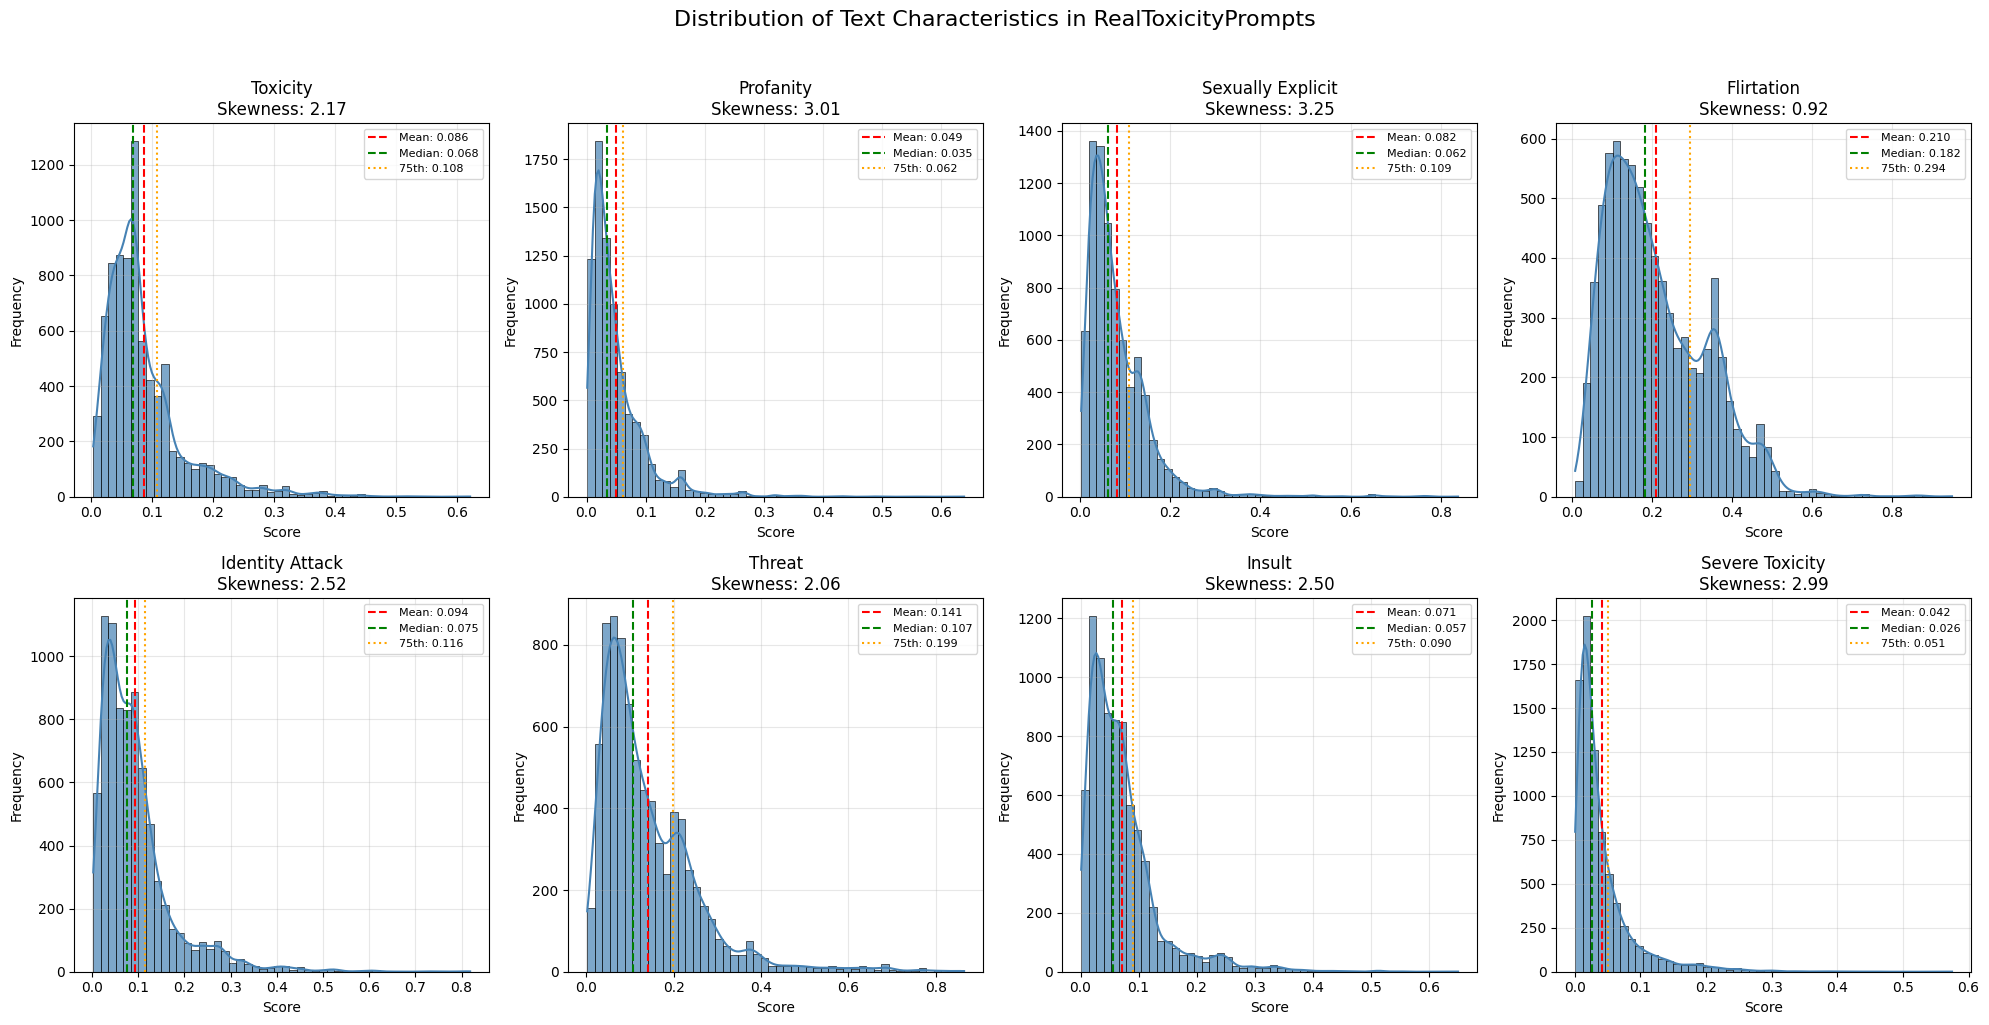


STATISTICAL SUMMARY
   Characteristic   Mean Median    Std Skewness Kurtosis 95th Percentile 99th Percentile
         toxicity 0.0863 0.0685 0.0674    2.174    6.655          0.2243          0.3503
        profanity 0.0491 0.0346 0.0480    3.013   15.429          0.1416          0.2503
sexually_explicit 0.0816 0.0621 0.0707    3.250   19.531          0.1952          0.3429
       flirtation 0.2105 0.1819 0.1236    0.918    0.935          0.4398          0.5156
  identity_attack 0.0938 0.0753 0.0818    2.518   10.028          0.2620          0.4137
           threat 0.1408 0.1075 0.1128    2.064    6.408          0.3496          0.6064
           insult 0.0710 0.0566 0.0634    2.500    9.439          0.2004          0.3275
  severe_toxicity 0.0417 0.0257 0.0473    2.989   12.925          0.1372          0.2347

THRESHOLD ESTIMATION

Recommended thresholds (by method):

   Characteristic Mean+1σ 75th %ile 90th %ile 95th %ile IQR (Q3+1.5*IQR)
         toxicity  0.1537    0.1077    0.1741

/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

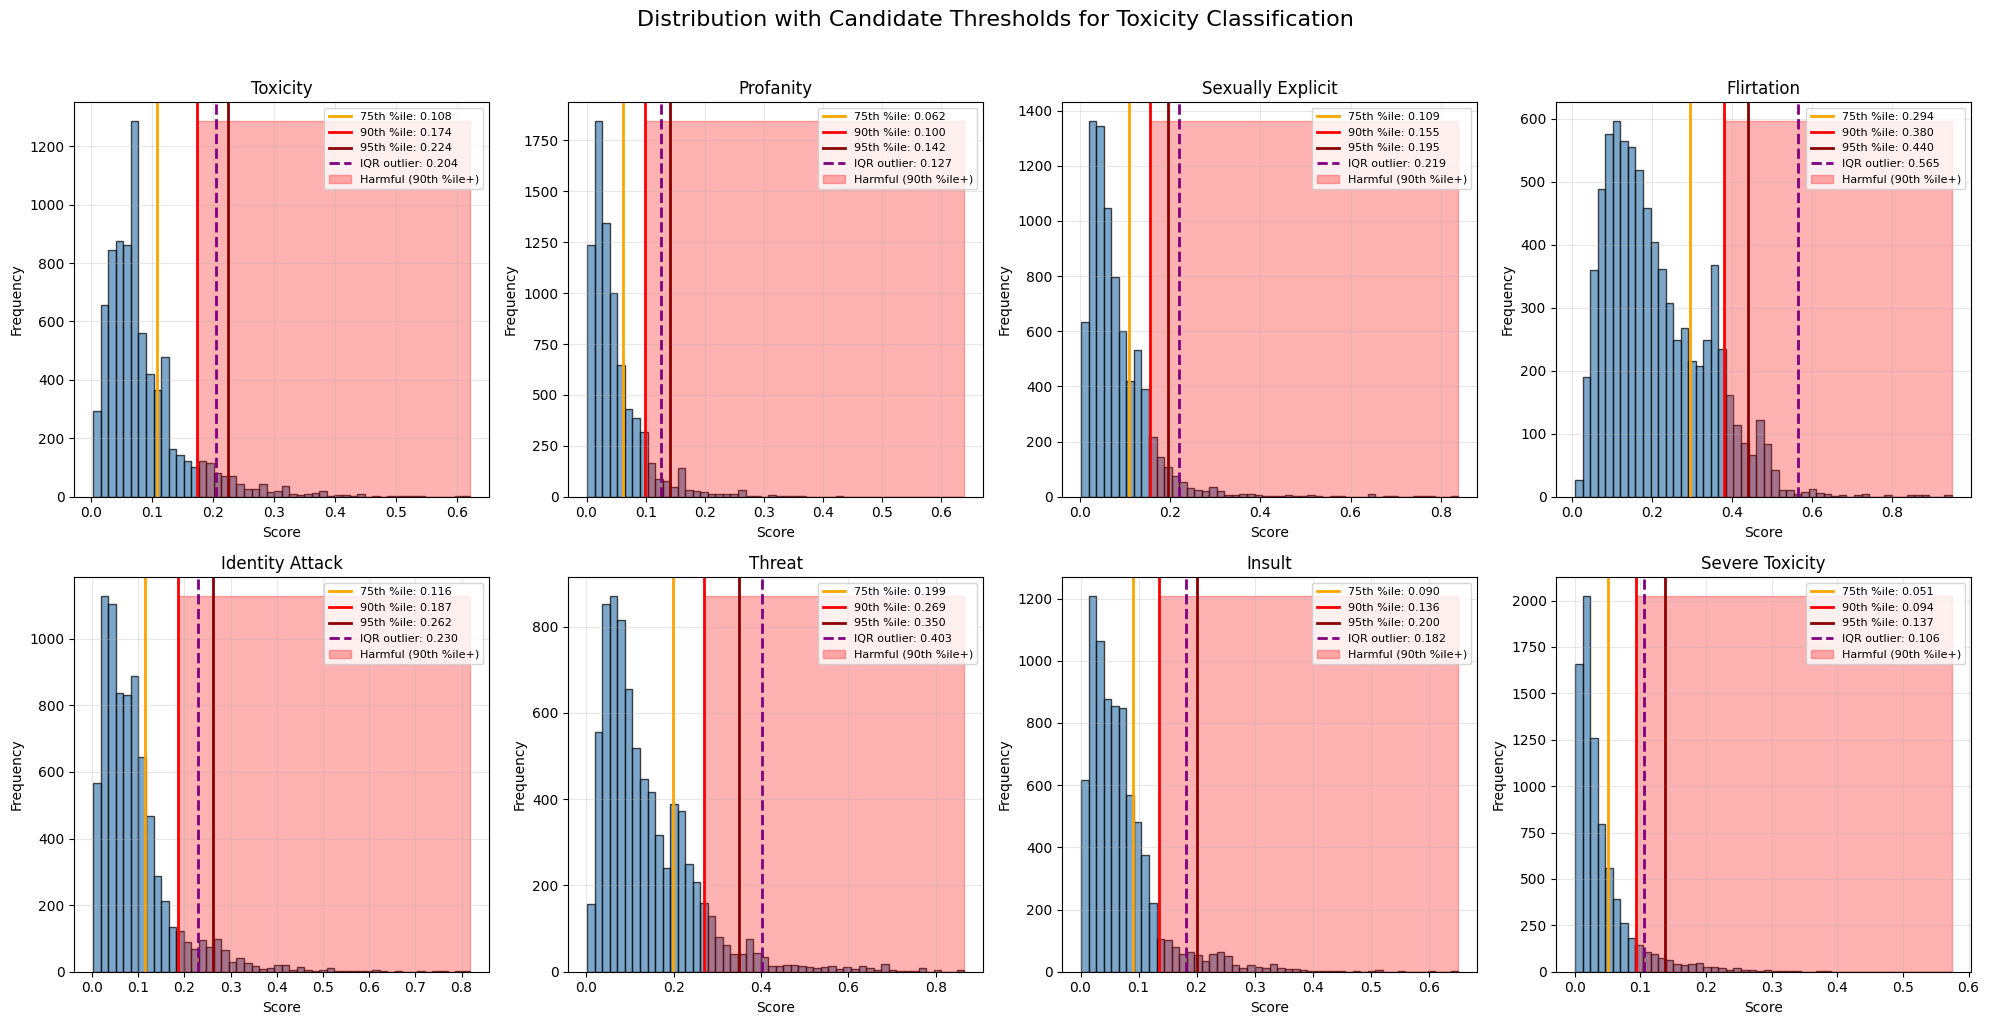

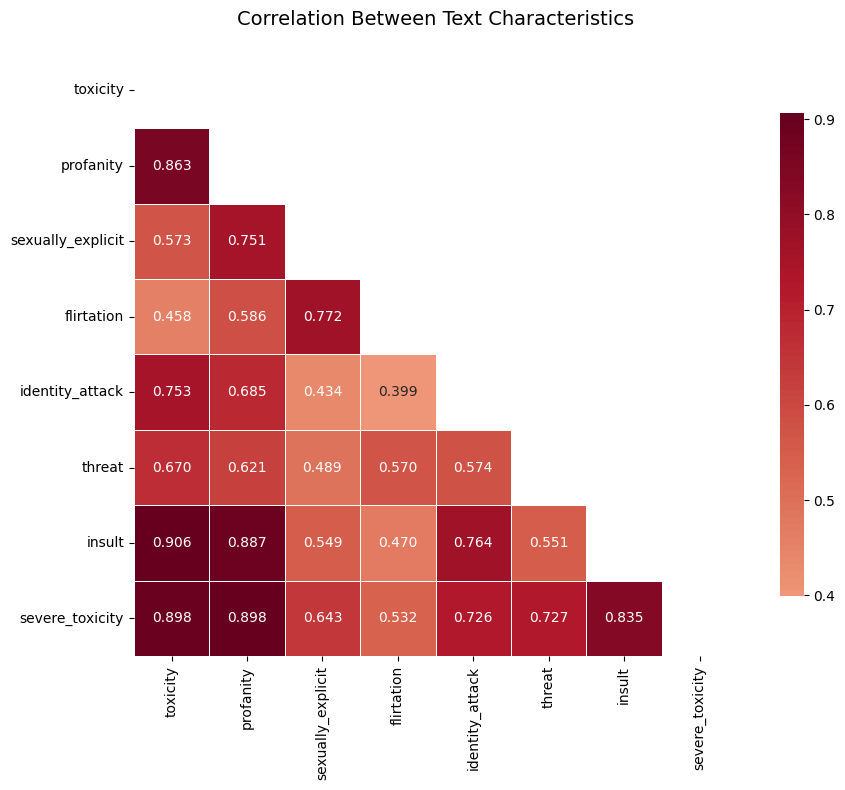

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from scipy import stats



# Extract all text characteristics
characteristics = ['toxicity', 'profanity', 'sexually_explicit', 'flirtation', 
                   'identity_attack', 'threat', 'insult', 'severe_toxicity']

# Collect data from prompts (since your example shows prompt has the main scores)
data = {char: [] for char in characteristics}

print("Extracting characteristics...")
for i, ex in enumerate(ds):
    if i > N_SAMPLES:
        break
    prompt_scores = ex['prompt']
    for char in characteristics:
        if char in prompt_scores:
            data[char].append(prompt_scores[char])
    
    # Limit for memory - use 100k samples for distribution analysis
    if i >= 100000:
        break

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Collected {len(df)} samples")

# ============================================================
# 1. DISTRIBUTION PLOTS FOR ALL CHARACTERISTICS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, char in enumerate(characteristics):
    ax = axes[idx]
    
    # Histogram with KDE
    sns.histplot(df[char], bins=50, kde=True, ax=ax, color='steelblue', alpha=0.7)
    
    # Statistics
    mean_val = df[char].mean()
    median_val = df[char].median()
    percentile_75 = df[char].quantile(0.75)
    percentile_90 = df[char].quantile(0.90)
    
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.3f}')
    ax.axvline(percentile_75, color='orange', linestyle=':', label=f'75th: {percentile_75:.3f}')
    
    ax.set_title(f'{char.replace("_", " ").title()}\nSkewness: {df[char].skew():.2f}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Text Characteristics in RealToxicityPrompts', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('characteristics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 2. STATISTICAL SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

summary_stats = []
for char in characteristics:
    summary_stats.append({
        'Characteristic': char,
        'Mean': f"{df[char].mean():.4f}",
        'Median': f"{df[char].median():.4f}",
        'Std': f"{df[char].std():.4f}",
        'Skewness': f"{df[char].skew():.3f}",
        'Kurtosis': f"{df[char].kurtosis():.3f}",
        '95th Percentile': f"{df[char].quantile(0.95):.4f}",
        '99th Percentile': f"{df[char].quantile(0.99):.4f}"
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

# ============================================================
# 3. THRESHOLD ESTIMATION USING MULTIPLE METHODS
# ============================================================
print("\n" + "="*80)
print("THRESHOLD ESTIMATION")
print("="*80)

thresholds = {}

# Method 1: Mean + 1 Standard Deviation
for char in characteristics:
    thresholds[f'{char}_mean+1std'] = df[char].mean() + df[char].std()

# Method 2: 75th Percentile (Q3)
for char in characteristics:
    thresholds[f'{char}_75th_percentile'] = df[char].quantile(0.75)

# Method 3: 90th Percentile (typical for outlier detection)
for char in characteristics:
    thresholds[f'{char}_90th_percentile'] = df[char].quantile(0.90)

# Method 4: 2 Standard Deviations from Mean (Gaussian assumption)
for char in characteristics:
    thresholds[f'{char}_2std'] = df[char].mean() + 2 * df[char].std()

# Method 5: Interquartile Range (IQR) method (Q3 + 1.5*IQR)
for char in characteristics:
    Q1 = df[char].quantile(0.25)
    Q3 = df[char].quantile(0.75)
    IQR = Q3 - Q1
    thresholds[f'{char}_iqr_outlier'] = Q3 + 1.5 * IQR

# Create threshold table
threshold_df = pd.DataFrame([
    {'Characteristic': char.split('_')[0], 
     'Method': method, 
     'Threshold': value}
    for method, value in thresholds.items()
    for char in [method]  # Hack for iteration
])

# Better: Direct table
print("\nRecommended thresholds (by method):\n")
threshold_table = []
for char in characteristics:
    threshold_table.append({
        'Characteristic': char,
        'Mean+1σ': f"{df[char].mean() + df[char].std():.4f}",
        '75th %ile': f"{df[char].quantile(0.75):.4f}",
        '90th %ile': f"{df[char].quantile(0.90):.4f}",
        '95th %ile': f"{df[char].quantile(0.95):.4f}",
        'IQR (Q3+1.5*IQR)': f"{df[char].quantile(0.75) + 1.5*(df[char].quantile(0.75)-df[char].quantile(0.25)):.4f}"
    })

threshold_table_df = pd.DataFrame(threshold_table)
print(threshold_table_df.to_string(index=False))

# ============================================================
# 4. OPTIMAL THRESHOLD FOR BINARY CLASSIFICATION
# ============================================================
print("\n" + "="*80)
print("OPTIMAL BINARY CLASSIFICATION THRESHOLDS")
print("="*80)

# For demonstration, we'll use 'toxicity' as the primary metric
# Load a sample with labels (if you have them, otherwise simulate)
# Assuming 'toxicity' > threshold = harmful

# Method: Use percentiles to define "high" toxicity
percentiles_to_test = [70, 75, 80, 85, 90, 95]

optimal_thresholds = {}
for char in characteristics:
    texts = df[char].values
    
    # For each candidate threshold (based on percentiles)
    best_f1 = 0
    best_threshold = 0.5
    
    # Simulate binary labels based on upper tail
    # This is self-consistent: top 20% = harmful
    for percentile in percentiles_to_test:
        threshold = np.percentile(texts, percentile)
        pred_labels = (texts > threshold).astype(int)
        true_labels = (texts > np.percentile(texts, 85)).astype(int)  # Assume top 15% are truly harmful
        
        f1 = f1_score(true_labels, pred_labels)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds[char] = {
        'threshold': best_threshold,
        'percentile': 100 * np.mean(texts <= best_threshold),
        'f1_score': best_f1
    }

optimal_df = pd.DataFrame([
    {'Characteristic': k, 
     'Optimal Threshold': v['threshold'],
     'Percentile': f"{v['percentile']:.1f}%",
     'F1 Score': f"{v['f1_score']:.3f}"}
    for k, v in optimal_thresholds.items()
])
print(optimal_df.to_string(index=False))

# ============================================================
# 5. VISUALIZE THRESHOLDS ON DISTRIBUTIONS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, char in enumerate(characteristics):
    ax = axes[idx]
    
    # Distribution
    n, bins, patches = ax.hist(df[char], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add threshold lines
    threshold_75 = df[char].quantile(0.75)
    threshold_90 = df[char].quantile(0.90)
    threshold_95 = df[char].quantile(0.95)
    threshold_iqr = df[char].quantile(0.75) + 1.5 * (df[char].quantile(0.75) - df[char].quantile(0.25))
    
    ax.axvline(threshold_75, color='orange', linestyle='-', linewidth=2, label=f'75th %ile: {threshold_75:.3f}')
    ax.axvline(threshold_90, color='red', linestyle='-', linewidth=2, label=f'90th %ile: {threshold_90:.3f}')
    ax.axvline(threshold_95, color='darkred', linestyle='-', linewidth=2, label=f'95th %ile: {threshold_95:.3f}')
    ax.axvline(threshold_iqr, color='purple', linestyle='--', linewidth=2, label=f'IQR outlier: {threshold_iqr:.3f}')
    
    # Highlight the "harmful" region (above threshold)
    y_max = max(n)
    x_fill = bins[bins >= threshold_90]
    if len(x_fill) > 0:
        ax.fill_betweenx([0, y_max], threshold_90, bins[-1], alpha=0.3, color='red', label='Harmful (90th %ile+)')
    
    ax.set_title(f'{char.replace("_", " ").title()}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution with Candidate Thresholds for Toxicity Classification', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('thresholds_on_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df[characteristics].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax, 
            cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Between Text Characteristics', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('characteristics_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
texts = []
labels = []

for i, ex in enumerate(ds):
    if i >= N_SAMPLES:
        break
    text = ex['prompt']['text'] 
    label = {**ex['prompt']}
    label.pop('text')
    texts.append(text)
    labels.append(label)

In [ ]:
# ------------------ 2. LOAD MODEL ------------------
print("Loading Qwen3-4B...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    # fold_ln=True,
    # center_writing_weights=True,
    # center_unembed=True,
    dtype=torch.bfloat16,
    trust_remote_code=True,   # important for Qwen
)

print(f"Loaded model with {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")

Loading Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Loaded model with 36 layers, d_model=2560


In [8]:
# ------------------ 3. LINEAR PROBE ------------------
class LinearProbe(nn.Module):
    def __init__(self, d_model, n_categories, sigmoid=False):
        super().__init__()
        self.linear = nn.Linear(d_model, n_categories)
        self.sigmoid = sigmoid
    
    def forward(self, x):
        x = self.linear(x)
        if self.sigmoid:
            x = torch.nn.functional.sigmoid(x)
        return x

In [9]:
AGG_FUNCS_ACTIVATIONS = {
    'mean': lambda x: x.mean(dim=1).cpu(), 
    'last': lambda x: x[:, -1, :].cpu()
}

In [10]:
SIGMOID_PROBE = True

In [11]:
# # ====================== SAVE ACTIVATIONS PER BATCH ======================
# def save_activations(texts, labels, split_name="all"):
#     """Save activations batch-by-batch to avoid OOM"""
#     # tokenizer = model.tokenizer
#     for act_type in ACTIVATION_TYPES:
#         for rel_p in LAYER_PERCENTAGES:
#             layer_idx = int(rel_p * model.cfg.n_layers)
#             act_dir = f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split_name}"
#             os.makedirs(act_dir, exist_ok=True)
            
#             for i in tqdm(range(0, N_SAMPLES, BATCH_SIZE), desc=f"{act_type} L{layer_idx} {split_name}"):
#                 batch_texts = texts[i:i+BATCH_SIZE]
#                 batch_labels = labels[i:i+BATCH_SIZE]
                
#                 # tokens = tokenizer(batch_texts, padding=True, truncation=True,
#                 #                  max_length=1024, return_tensors="pt").input_ids.to(DEVICE)
                
#                 tokens = model.to_tokens(batch_texts)
#                 with torch.no_grad():
#                     _, cache = model.run_with_cache(
#                         tokens,
#                         names_filter=lambda n: n == utils.get_act_name(act_type, layer_idx),
#                         return_type=None
#                     )
                    
#                     act = cache[utils.get_act_name(act_type, layer_idx)]  # (batch, seq, d)
#                     pooled = act.mean(dim=1).cpu()  # or act[:, -1, :] for last token
                    
#                     # Save batch
#                     torch.save({
#                         "activations": pooled,
#                         "labels": batch_labels
#                     }, f"{act_dir}/batch_{i//BATCH_SIZE:06d}.pt")
                    
#                     del cache, act, pooled
#                     gc.collect()
#                     torch.cuda.empty_cache()


import torch
import gc
import os
from tqdm import tqdm

# ====================== SAVE ACTIVATIONS PER BATCH ======================
def save_activations(texts, labels, split_name="all", agg_func='last'):
    """Save activations batch-by-batch to avoid OOM"""
    
    # Filter out invalid texts
    valid_indices = [i for i, text in enumerate(texts) if text and isinstance(text, str) and len(text.strip()) > 0]
    valid_texts = [texts[i] for i in valid_indices]
    valid_labels = [labels[i] for i in valid_indices]
    
    print(f"Filtered out {len(texts) - len(valid_texts)} invalid samples")
    
    if len(valid_texts) == 0:
        print("No valid texts found!")
        return
    
    for act_type in ACTIVATION_TYPES:
        for rel_p in LAYER_PERCENTAGES:
            layer_idx = int(rel_p * model.cfg.n_layers)
            act_dir = f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split_name}"
            os.makedirs(act_dir, exist_ok=True)
            
            for i in tqdm(range(0, len(valid_texts), BATCH_SIZE), desc=f"{act_type} L{layer_idx} {split_name}"):
                batch_texts = valid_texts[i:i+BATCH_SIZE]
                batch_labels = valid_labels[i:i+BATCH_SIZE]
                
                # Skip empty batches
                if not batch_texts:
                    continue
                
                try:
                    # Method 1: Try to_tokens first
                    tokens = model.to_tokens(batch_texts, truncate=True)
                    
                    # Check if tokens are valid
                    if tokens is None or tokens.numel() == 0:
                        print(f"Warning: Empty tokens for batch {i//BATCH_SIZE}")
                        continue
                    
                    with torch.no_grad():
                        _, cache = model.run_with_cache(
                            tokens,
                            names_filter=lambda n: n == utils.get_act_name(act_type, layer_idx),
                            return_type=None
                        )
                        
                        act = cache[utils.get_act_name(act_type, layer_idx)]  # (batch, seq, d)
                        # pooled = act.mean(dim=1).cpu()  # or act[:, -1, :] for last token
                        for agg_func_name, act_func in AGG_FUNCS_ACTIVATIONS.items():

                            pooled = act_func(act)
                            
                            # Save batch
                            torch.save({
                                "activations": pooled,
                                "labels": batch_labels
                            }, f"{act_dir}/batch_{i//BATCH_SIZE:06d}_{agg_func_name}.pt")
                        
                        del cache, act, pooled
                        gc.collect()
                        torch.cuda.empty_cache()
                        
                except Exception as e:
                    print(f"Error processing batch {i//BATCH_SIZE}: {e}")
                    print(f"Batch texts sample: {batch_texts[:2]}")
                    continue

In [12]:
# save_activations(texts, labels)

In [14]:
def gather_full_tensor( act_type, layer_idx, split='all', agg_type='last'):
    files = sorted([
            f for f in os.listdir(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}")
            if f.endswith(".pt") and agg_type in f
     ])
    activations = []
    scores = []
    for file in files:
        f = torch.load(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}/{file}")
        for score in f['labels']:
            pre_check = list(score.values())
            if any(pre_check_i is None for pre_check_i in pre_check):
                pre_check = [0.] * len(pre_check)
            scores.append(pre_check)        
        activations.append(f['activations'])
        
    activations = torch.cat(
        activations, dim=0
    )
    scores = torch.tensor(np.array(scores), dtype=torch.float32)
    return activations, scores

# ====================== LOAD DATASET FROM DISK ======================
class ActivationDataset(torch.utils.data.Dataset):
    def __init__(self, act_type, layer_idx, split="all", gathering_func=gather_full_tensor, agg_type='last'):
        self.data, self.labels = gathering_func(act_type, layer_idx, split, agg_type)

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        data = self.data[idx]
        return data, self.labels[idx]

In [15]:
EPOCHS = 200

In [97]:
# ====================== TRAINING (MULTIVARIATE REGRESSION WITH PER-TARGET METRICS) ======================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product 

results = []

for act_type, rel_p, agg_type in product(ACTIVATION_TYPES, LAYER_PERCENTAGES, AGG_FUNCS_ACTIVATIONS):
    try:
        layer_idx = int(rel_p * 36)
        print(f"\n=== Training regression probe: {act_type} @ layer {layer_idx} ({rel_p*100:.0f}%) ===")
        
        generator = torch.Generator().manual_seed(42)
        full_dataset = ActivationDataset(act_type, layer_idx, 'all', agg_type=agg_type)  # Assumes continuous targets
        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset, lengths=[0.8, 0.2],
            generator=generator
        )
        
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)
        
        
        # Regression probe with multiple outputs
        n_targets =  full_dataset.labels.size(-1)
        probe = LinearProbe(full_dataset.data[0].size(-1), n_targets, True).to(torch.float32).to(DEVICE)
        
        optimizer = optim.AdamW(probe.parameters(), lr=LR, weight_decay=1e-1)
        criterion = nn.MSELoss()  # Computes loss across all targets
        
        best_val_r2 = -float('inf')
        best_state = None
        best_metrics = {}
        
        for epoch in range(EPOCHS):
            # Training
            probe.train()
            epoch_train_loss = 0.0
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(DEVICE).to(torch.float32), yb.to(DEVICE).to(torch.float32)
                optimizer.zero_grad()
                predictions = probe(Xb)
                loss = criterion(predictions, yb)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
            
            avg_train_loss = epoch_train_loss / len(train_loader)
            
            # Validation
            probe.eval()
            val_preds, val_true = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb = Xb.to(torch.float32).to(DEVICE)
                    preds = probe(Xb).cpu().numpy()
                    val_preds.append(preds)
                    val_true.append(yb.numpy())
            
            val_preds = np.concatenate(val_preds, axis=0)
            val_true = np.concatenate(val_true, axis=0)
            
            # Overall metrics
            overall_mse = mean_squared_error(val_true, val_preds)
            overall_rmse = np.sqrt(overall_mse)
            overall_mae = mean_absolute_error(val_true, val_preds)
            overall_r2 = r2_score(val_true, val_preds)
            
            # Per-target metrics
            per_target_mse = []
            per_target_rmse = []
            per_target_mae = []
            per_target_r2 = []
            
            for target_idx in range(n_targets):
                target_true = val_true[:, target_idx]
                target_pred = val_preds[:, target_idx]
                
                target_mse = mean_squared_error(target_true, target_pred)
                target_rmse = np.sqrt(target_mse)
                target_mae = mean_absolute_error(target_true, target_pred)
                target_r2 = r2_score(target_true, target_pred)
                
                per_target_mse.append(target_mse)
                per_target_rmse.append(target_rmse)
                per_target_mae.append(target_mae)
                per_target_r2.append(target_r2)
            
            # # Print metrics
            # print(f"\nEpoch {epoch+1:2d}")
            # print(f"  Overall: MSE={overall_mse:.4f}, RMSE={overall_rmse:.4f}, MAE={overall_mae:.4f}, R²={overall_r2:.4f}")
            
            # # Print first few targets (limit to avoid clutter)
            # n_print = min(5, n_targets)
            # print(f"  Per-target R² (first {n_print}): " + 
            #       ", ".join([f"T{i}: {per_target_r2[i]:.3f}" for i in range(n_print)]))
            # if n_targets > 5:
            #     print(f"    ... (total {n_targets} targets)")
            
            # Save best model based on overall R²
            if overall_r2 > best_val_r2:
                best_val_r2 = overall_r2
                best_metrics = {
                    'overall': {
                        'mse': overall_mse,
                        'rmse': overall_rmse,
                        'mae': overall_mae,
                        'r2': overall_r2
                    },
                    'per_target': {
                        'mse': per_target_mse,
                        'rmse': per_target_rmse,
                        'mae': per_target_mae,
                        'r2': per_target_r2
                    }
                }
                best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}

        # Load best model and save
        probe.load_state_dict(best_state)
        torch.save(best_state, f"{SAVE_DIR}/regression_probe_l{layer_idx}_{act_type}_{agg_type}.pt")
        
        # Store results with per-target info as JSON strings
        results.append({
            "layer_idx": layer_idx,
            "act_type": act_type,
            'agg_type': agg_type,
            "final_tr_loss": avg_train_loss,
            # Overall metrics
            "overall_mse": best_metrics['overall']['mse'],
            "overall_rmse": best_metrics['overall']['rmse'],
            "overall_mae": best_metrics['overall']['mae'],
            "overall_r2": best_metrics['overall']['r2'],
            # Per-target metrics (stored as lists/JSON)
            "per_target_mse": best_metrics['per_target']['mse'],
            "per_target_rmse": best_metrics['per_target']['rmse'],
            "per_target_mae": best_metrics['per_target']['mae'],
            "per_target_r2": best_metrics['per_target']['r2'],
            "n_targets": n_targets
        })
    except:
        import traceback 
        print((act_type, rel_p, agg_type), traceback.format_exc())
        continue

# Convert to DataFrame and expand per-target columns if needed
results_df = pd.DataFrame(results)

# Option 1: Save with per-target lists as JSON strings
# results_df['per_target_mse'] = results_df['per_target_mse'].apply(lambda x: str(x))
# results_df['per_target_rmse'] = results_df['per_target_rmse'].apply(lambda x: str(x))
# results_df['per_target_mae'] = results_df['per_target_mae'].apply(lambda x: str(x))
# results_df['per_target_r2'] = results_df['per_target_r2'].apply(lambda x: str(x))
results_df.to_csv('lin_probes_regression_per_target.csv', index=False)

# Option 2: Create separate rows for each target (tidy format)
tidy_results = []
for _, row in results_df.iterrows():
    for target_idx in range(row['n_targets']):
        tidy_results.append({
            'layer_idx': row['layer_idx'],
            'act_type': row['act_type'],
            'target_idx': target_idx,
            'mse': row['per_target_mse'][target_idx],
            'rmse': row['per_target_rmse'][target_idx],
            'mae': row['per_target_mae'][target_idx],
            'r2': row['per_target_r2'][target_idx],
            'final_tr_loss': row['final_tr_loss']
        })

tidy_results_df = pd.DataFrame(tidy_results)
tidy_results_df.to_csv('lin_probes_regression_per_target_tidy.csv', index=False)

print("Done. Results saved in two formats:")
print("  - Wide format with per-target lists: lin_probes_regression_per_target.csv")
print("  - Tidy format (one row per target): lin_probes_regression_per_target_tidy.csv")


=== Training regression probe: resid_post @ layer 14 (40%) ===

=== Training regression probe: resid_post @ layer 14 (40%) ===

=== Training regression probe: resid_post @ layer 18 (50%) ===

=== Training regression probe: resid_post @ layer 18 (50%) ===

=== Training regression probe: resid_post @ layer 21 (60%) ===

=== Training regression probe: resid_post @ layer 21 (60%) ===

=== Training regression probe: resid_post @ layer 28 (80%) ===

=== Training regression probe: resid_post @ layer 28 (80%) ===

=== Training regression probe: resid_post @ layer 32 (90%) ===

=== Training regression probe: resid_post @ layer 32 (90%) ===

=== Training regression probe: resid_mid @ layer 14 (40%) ===

=== Training regression probe: resid_mid @ layer 14 (40%) ===

=== Training regression probe: resid_mid @ layer 18 (50%) ===

=== Training regression probe: resid_mid @ layer 18 (50%) ===

=== Training regression probe: resid_mid @ layer 21 (60%) ===

=== Training regression probe: resid_mid @ l

In [16]:
results_df = pd.read_csv('lin_probes_regression_per_target.csv')

# results_df = pd.DataFrame(results)

In [17]:
df = results_df[['layer_idx', 'act_type', 'agg_type', 'per_target_r2']]

In [18]:
type(df.iloc[0, -1])

str

In [19]:
import ast 


expanded_df = pd.DataFrame(
    df['per_target_r2'].apply(lambda x: x if not isinstance(x, str) else ast.literal_eval(x)).tolist(),
    columns=[f'per_target_r2_{i}' for i in range(8)]
)

# Combine with original columns (drop the original list column)
result_df = pd.concat([df.drop('per_target_r2', axis=1), expanded_df], axis=1)

print(result_df)

    layer_idx    act_type agg_type  per_target_r2_0  per_target_r2_1  \
0          14  resid_post     mean         0.220544         0.142209   
1          14  resid_post     last         0.060127         0.025947   
2          18  resid_post     mean         0.210297         0.120113   
3          18  resid_post     last         0.073079         0.027725   
4          21  resid_post     mean         0.218050         0.108504   
5          21  resid_post     last        -0.010241        -0.033745   
6          28  resid_post     mean         0.125869         0.000973   
7          28  resid_post     last        -1.497333        -0.969200   
8          32  resid_post     mean        -1.497917        -1.001822   
9          32  resid_post     last        -1.594418        -0.970527   
10         14   resid_mid     mean         0.228154         0.122736   
11         14   resid_mid     last         0.041275         0.019195   
12         18   resid_mid     mean         0.222137         0.12

In [20]:
result_df

,layer_idx,act_type,agg_type,per_target_r2_0,per_target_r2_1,per_target_r2_2,per_target_r2_3,per_target_r2_4,per_target_r2_5,per_target_r2_6,per_target_r2_7
0,14,resid_post,mean,0.220544,0.142209,0.065465,0.144211,0.281965,0.249993,0.159350,0.135515
1,14,resid_post,last,0.060127,0.025947,-0.014969,0.020993,0.113260,0.060450,0.042442,0.032932
2,18,resid_post,mean,0.210297,0.120113,0.031509,0.127795,0.236727,0.262801,0.160665,0.158090
3,18,resid_post,last,0.073079,0.027725,-0.029614,-0.027073,0.098082,0.065182,0.007545,0.011234
4,21,resid_post,mean,0.218050,0.108504,0.013782,0.125712,0.278753,0.241283,0.128904,0.113191
5,21,resid_post,last,-0.010241,-0.033745,-0.058891,-0.023495,0.041794,-0.005594,-0.019833,-0.039493
6,28,resid_post,mean,0.125869,0.000973,-0.140152,-0.048117,0.092099,0.094911,-0.029152,0.036164
7,28,resid_post,last,-1.497333,-0.969200,-1.191841,-0.450872,-0.256709,-0.384324,-0.226883,-0.637349
8,32,resid_post,mean,-1.497917,-1.001822,-1.204066,-0.165433,-1.114444,-1.454950,-0.274633,-0.712479
9,32,resid_post,last,-1.594418,-0.970527,-1.226751,-2.713967,-1.340461,-1.454355,-1.191314,-0.785244


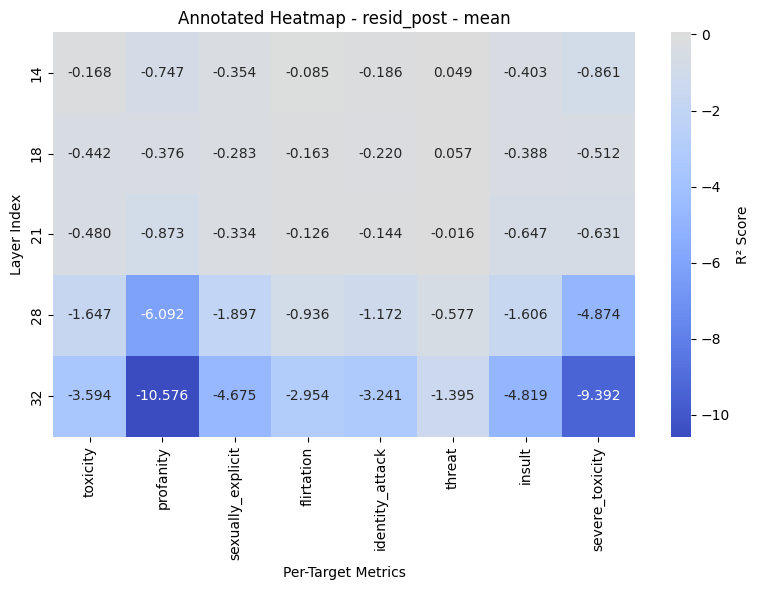

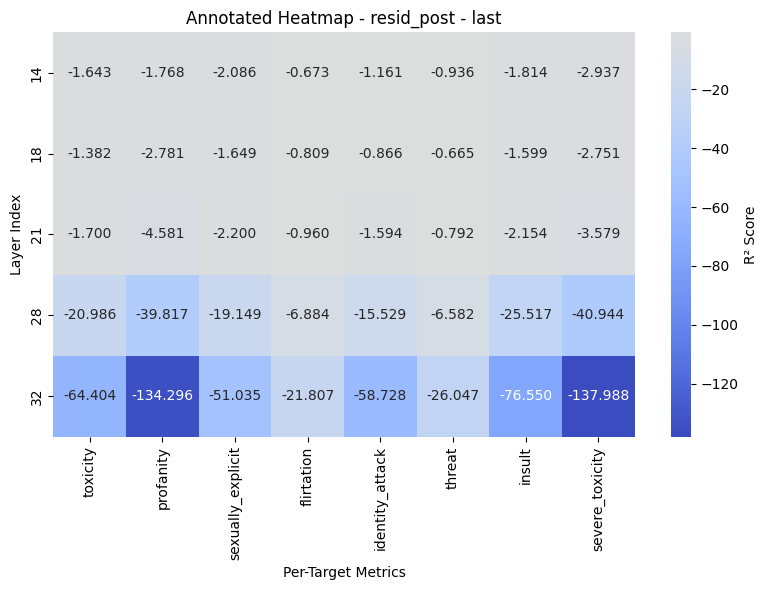

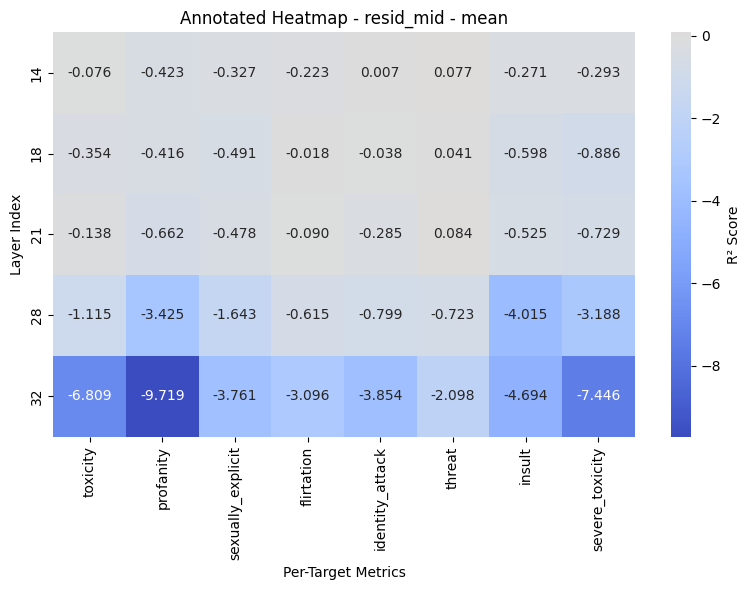

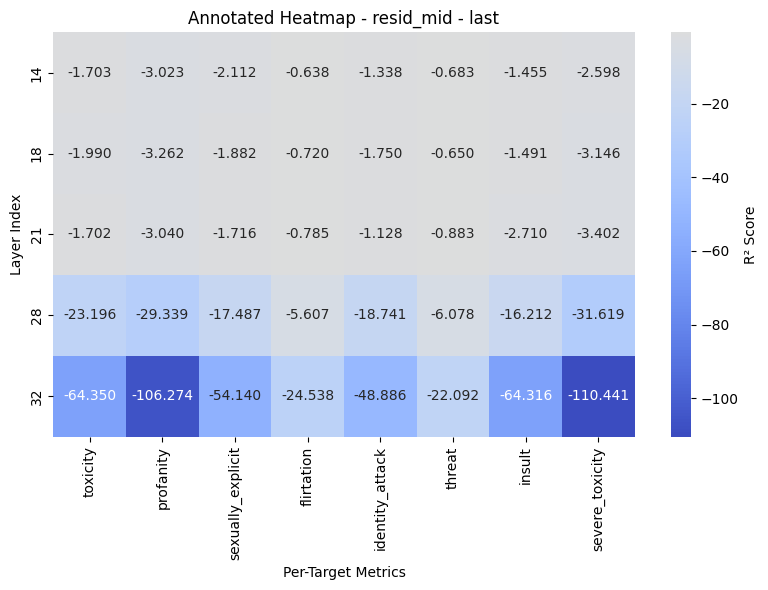

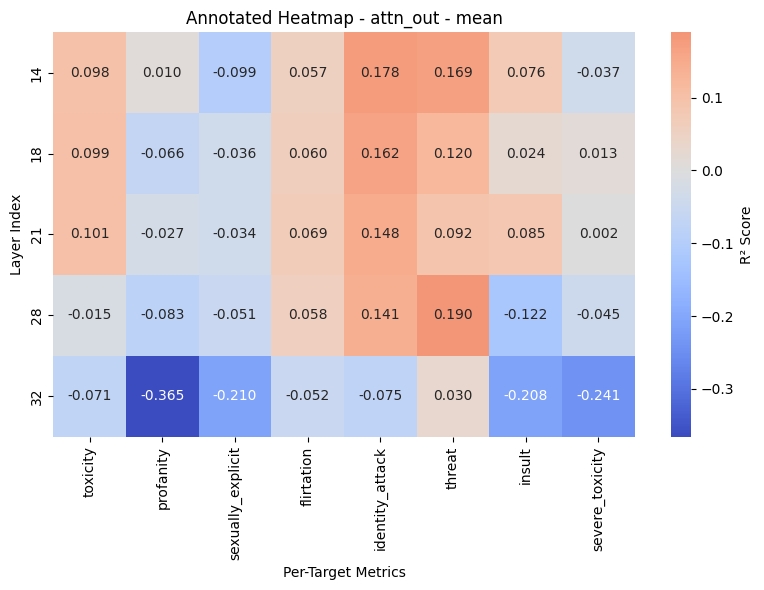

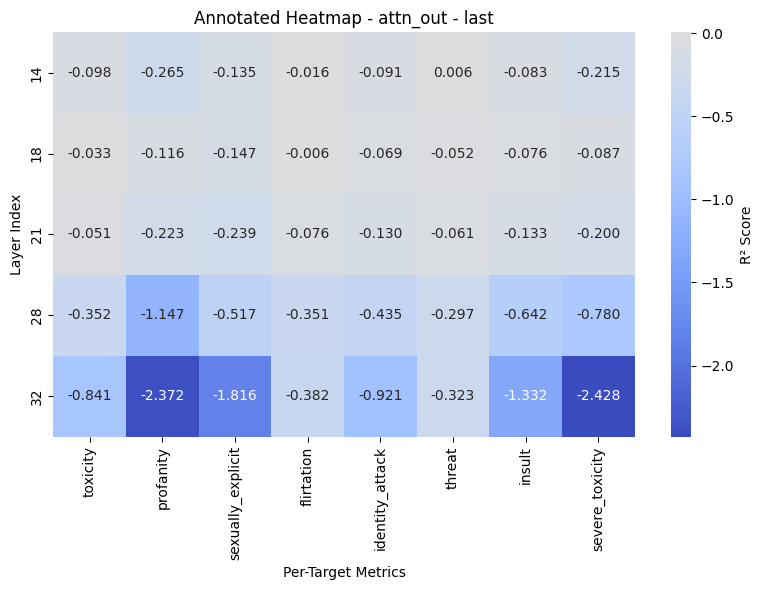

In [100]:
for act_type, agg_type in product(ACTIVATION_TYPES, AGG_FUNCS_ACTIVATIONS):

        subset = result_df[(result_df['act_type'] == act_type) & (result_df['agg_type'] == agg_type)].set_index('layer_idx')
        metric_cols = [c for c in result_df.columns if not c in ('act_type', 'layer_idx', 'agg_type')]
        heatmap_data = subset[metric_cols]
        heatmap_data.columns = TARGETS
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='coolwarm', 
                    center=0, cbar_kws={'label': 'R² Score'})
        plt.title(f'Annotated Heatmap - {act_type} - {agg_type}')
        plt.ylabel('Layer Index')
        plt.xlabel('Per-Target Metrics')
        plt.tight_layout()
        plt.show()


#### Create WDMP Embeddings

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm import tqdm
import json, os, gc
from datasets import load_dataset
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils

# ====================== CONFIG ======================
MODEL_NAME = "Qwen/Qwen3-4B"
DEVICE = "cuda"
BATCH_SIZE = 8          # Very conservative for 8B
EPOCHS = 16
LR = 5e-4

# ACTIVATION_TYPES = [
#     "resid_post",
#     "resid_mid",
#                      "mlp_post", 
#                      "attn_out"
#                      ]  # Add more as needed
# LAYER_PERCENTAGES = [
#     0.4,
#       0.5, 0.6, 0.8, 0.9, 
#                     #  1.0
#                      ]

SAVE_DIR = "./harmfulness_activations_qwen3_WDMP"
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
# ------------------ 2. LOAD MODEL ------------------
print("Loading Qwen3-4B...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    # fold_ln=True,
    # center_writing_weights=True,
    # center_unembed=True,
    dtype=torch.bfloat16,
    trust_remote_code=True,   # important for Qwen
)

print(f"Loaded model with {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")

Loading Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Loaded model with 36 layers, d_model=2560


In [102]:
from datasets import load_dataset

ds = load_dataset("cais/wmdp", "wmdp-bio")['test']



In [105]:
N_WMDP = 400

In [ ]:

texts = []
labels = []

for i, ex in enumerate(ds, 1):
    if i > N_WMDP:
        break
    text = ex['question']
    label = ex['question']#, ex['choices'], ex['question'])
    texts.append(text)
    labels.append(label)

In [26]:
# save_activations(texts, labels)

In [51]:
def gather_full_tensor_wdmp( act_type, layer_idx, split='all', agg_type='last'):
    files = sorted([
            f for f in os.listdir(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}")
            if f.endswith(".pt") and agg_type in f
     ])
    activations = []
    texts = []
    for file in files:
        f = torch.load(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}/{file}")
        texts.append(f['labels'])        
        activations.append(f['activations'])
        
    activations = torch.cat(
        activations, dim=0
    )
    texts = [t[-1] for t in texts]
    return activations, texts



In [28]:
n_targets = 8

In [29]:
# result = []

# for act_type in ACTIVATION_TYPES:
#     for rel_p in LAYER_PERCENTAGES:
#         layer_idx = int(rel_p * 36)
#         print(f"\n=== Training regression probe: {act_type} @ layer {layer_idx} ({rel_p*100:.0f}%) ===")
        
#         probe_state = torch.load(f'/home/leostre/Рабочий стол/evals_project/qwen/harmfulness_activations_qwen3_MixTox/regression_probe_l{layer_idx}_{act_type}.pt')
#         full_dataset = ActivationDataset(act_type, layer_idx, 'all', gathering_func=gather_full_tensor_wdmp)  # Assumes continuous targets
#         probe = LinearProbe(full_dataset.data.size(-1), n_targets)
#         probe.load_state_dict(probe_state)

#         # test_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)
#         output = probe(full_dataset.data.to(torch.float32))
        

In [52]:
# ====================== DATA PREPARATION ======================
def load_probe_data_cached(act_type, layer_idx, agg_type):
    """Cached data loading"""
    cache_key = f"{act_type}_{layer_idx}_{agg_type}"
    
    if not hasattr(load_probe_data_cached, 'cache'):
        load_probe_data_cached.cache = {}
    
    if cache_key in load_probe_data_cached.cache:
        return load_probe_data_cached.cache[cache_key]
    
    probe_path = f'/home/leostre/Рабочий стол/evals_project/qwen/harmfulness_activations_qwen3_MixTox/regression_probe_l{layer_idx}_{act_type}_{agg_type}.pt'
    full_dataset = ActivationDataset(act_type, layer_idx, 'all', gathering_func=gather_full_tensor_wdmp, agg_type=agg_type)
    
    probe_state = torch.load(probe_path)
    probe = LinearProbe(full_dataset.data.size(-1), n_targets, sigmoid=SIGMOID_PROBE)
    probe.load_state_dict(probe_state)
    probe.eval()
    
    with torch.no_grad():
        outputs = probe(full_dataset.data.to(torch.float32)).cpu().numpy()
        
        # Option 2: Per-target centering (across questions for each target)
        # Shape: (n_questions, n_targets)
        mean = np.mean(outputs, axis=0, keepdims=True)  # (1, n_targets)
        std = np.std(outputs, axis=0, keepdims=True)    # (1, n_targets)
        
        # Avoid division by zero
        std = np.where(std < 1e-8, 1.0, std)
        
        outputs = (outputs - mean) / std

    
    
    result = {
        'outputs': outputs,  # Shape: (n_questions, n_targets)
        'probe_weight': probe.linear.weight.detach().numpy(),
        'labels': full_dataset.labels,
        'activations': full_dataset.data,
        'n_samples': len(full_dataset.labels)
    }
    
    load_probe_data_cached.cache[cache_key] = result
    return result

In [60]:
load_probe_data_cached('resid_post', 14, 'mean').keys()

dict_keys(['outputs', 'probe_weight', 'labels', 'activations', 'n_samples'])

In [66]:
def np_sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [77]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dynamics(act_type, agg_type, n_layers, sigmoid=True):
    indices = [int(n_layers * prop) for prop in LAYER_PERCENTAGES]
    all_norms = []
    
    # Collect norms for each layer
    for index in indices: 
        probe_data = load_probe_data_cached(act_type, index, agg_type)['outputs']
        if sigmoid:
            probe_data = np_sigmoid(probe_data)

        norms = np.linalg.norm(probe_data, axis=-1)  # shape: (n_samples,)
        all_norms.append(norms)
    
    # Stack into shape: (n_layers, n_samples)
    all_norms = np.stack(all_norms, axis=0)
    
    # Option 1: Plot all samples with low alpha for density
    plt.figure(figsize=(12, 6))
    for i in range(all_norms.shape[1]):  # iterate over samples
        plt.plot(LAYER_PERCENTAGES, all_norms[:, i], alpha=0.3, color='blue', linewidth=0.5)
    
    plt.xlabel('Layer Progression')
    plt.ylabel('Norm of Activations')
    plt.title(f'By-Sample Norm Dynamics - {act_type} ({agg_type})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Option 2: Show statistics with individual samples
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: All samples with mean overlay
    for i in range(all_norms.shape[1]):
        ax1.plot(LAYER_PERCENTAGES, all_norms[:, i], alpha=0.2, color='blue', linewidth=0.5)
    
    mean_norms = np.mean(all_norms, axis=1)
    std_norms = np.std(all_norms, axis=1)
    ax1.plot(LAYER_PERCENTAGES, mean_norms, 'r-', linewidth=2, label='Mean')
    ax1.fill_between(LAYER_PERCENTAGES, mean_norms - std_norms, mean_norms + std_norms, 
                      alpha=0.2, color='red', label='±1 std')
    ax1.set_xlabel('Layer Progression')
    ax1.set_ylabel('Norm')
    ax1.set_title('All Samples with Statistics')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right: Heatmap of norms across samples and layers
    im = ax2.imshow(all_norms.T, aspect='auto', cmap='viridis', 
                    extent=[0, len(LAYER_PERCENTAGES)-1, 0, all_norms.shape[1]], 
                    origin='lower')
    ax2.set_xlabel('Layer Progression')
    ax2.set_ylabel('Sample Index')
    ax2.set_title('Norm Heatmap')

    # Set x-tick labels to show actual layer percentages
    ax2.set_xticks(range(len(LAYER_PERCENTAGES)))
    ax2.set_xticklabels([f'{p:.2f}' for p in LAYER_PERCENTAGES], rotation=45)

    plt.colorbar(im, ax=ax2, label='Norm')
    
    plt.tight_layout()
    plt.show()
    
    # Option 3: Box plot per layer (good for distribution)
    plt.figure(figsize=(12, 6))
    plt.boxplot(all_norms.T, positions=LAYER_PERCENTAGES, widths=0.02)
    plt.xlabel('Layer Progression')
    plt.ylabel('Norm')
    plt.title(f'Norm Distributions per Layer - {act_type} ({agg_type})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return all_norms


    

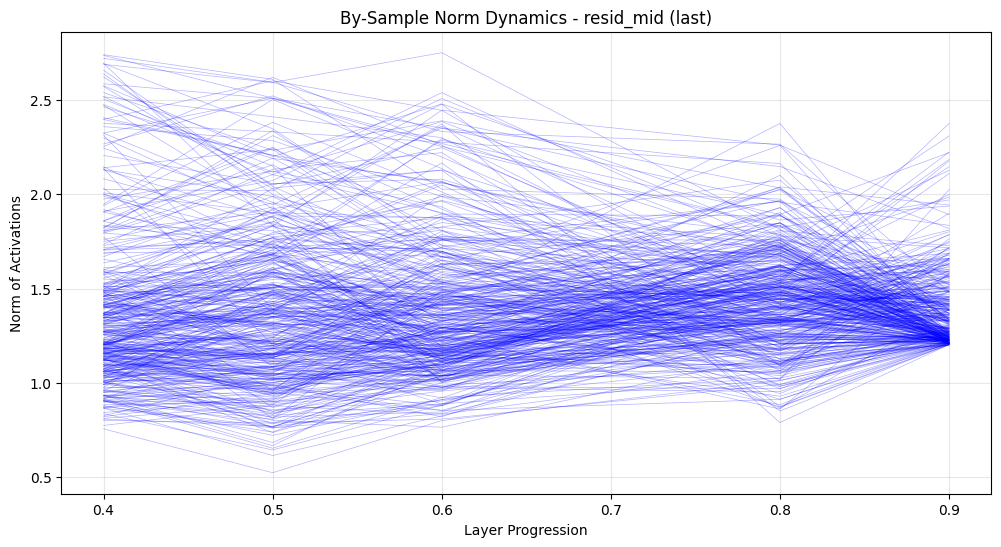

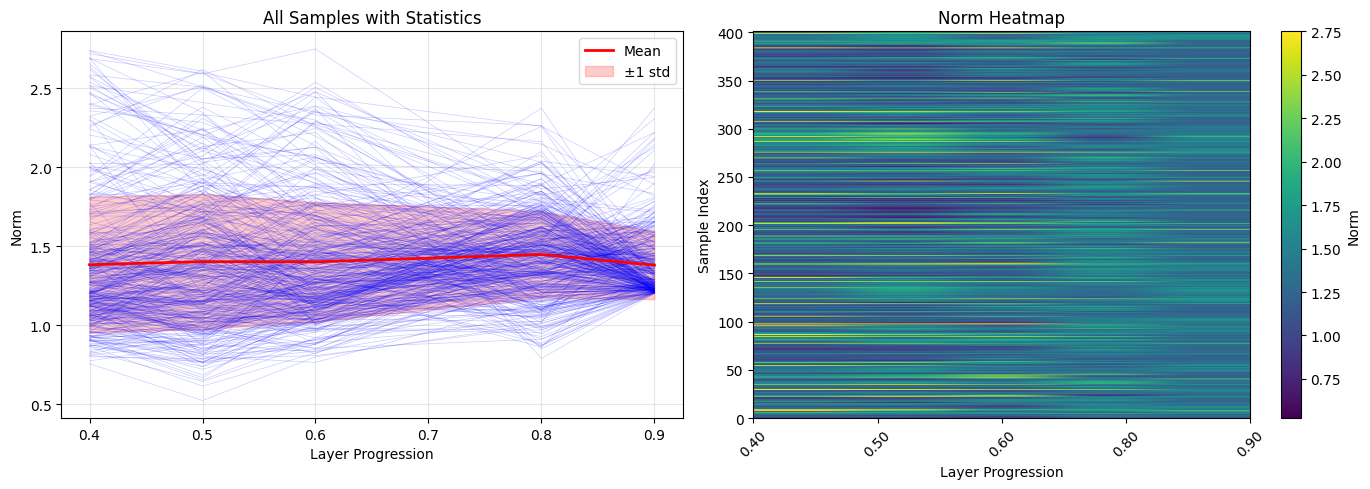

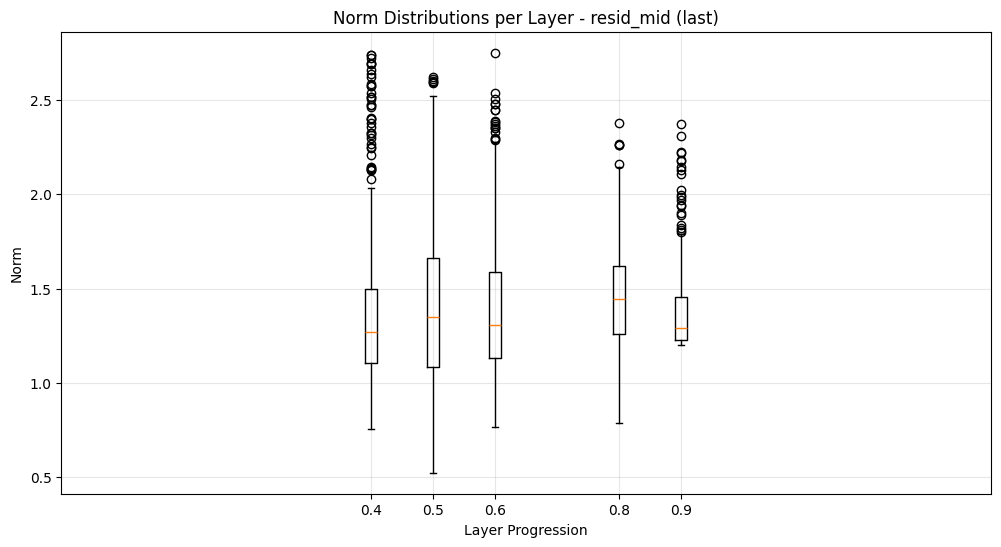

array([[1.0641637 , 1.1762439 , 1.143334  , ..., 2.47566   , 1.1901616 ,
        2.6217728 ],
       [0.9567204 , 1.2608172 , 1.0363874 , ..., 2.1175365 , 1.5757661 ,
        2.0495868 ],
       [1.0179132 , 0.97725475, 1.2714945 , ..., 2.385311  , 1.1629562 ,
        2.2472682 ],
       [1.2611511 , 1.3865609 , 1.4497294 , ..., 1.6989164 , 1.3217432 ,
        1.4868425 ],
       [1.2369534 , 1.2720258 , 1.3239839 , ..., 1.3376577 , 1.5061691 ,
        1.4310114 ]], dtype=float32)

In [78]:
plot_dynamics('resid_mid', 'last', 36)

In [ ]:
from ipywidgets import interact, fixed
import ipywidgets as widgets

@interact(
    act_type=widgets.Dropdown(options=ACTIVATION_TYPES, description='Act Type:'),
    agg_type=widgets.Dropdown(options=AGG_FUNCS_ACTIVATIONS.keys(), description='Agg Type:'),
    max_samples=widgets.IntSlider(value=50, min=10, max=200, step=10, description='Samples:'),
    show_heatmap=widgets.Checkbox(value=True, description='Heatmap'),
    normalize=widgets.Checkbox(value=False, description='Normalize')
)
def interactive_plot(act_type, agg_type, max_samples, show_heatmap, normalize, n_layers=36):
    """Interactive plotting function"""
    indices = [int(n_layers * prop) for prop in LAYER_PERCENTAGES]
    all_norms = []
    
    for index in indices: 
        probe_data = load_probe_data_cached(act_type, index, agg_type)
        norms = np.linalg.norm(probe_data['outputs'], axis=-1)
        all_norms.append(norms)
    
    all_norms = np.stack(all_norms, axis=0)
    
    # Apply normalization if selected
    if normalize:
        all_norms = all_norms / all_norms[0:1, :]
        ylabel = 'Relative Norm (normalized to layer 1)'
    else:
        ylabel = 'Norm'
    
    # Subsample if needed
    if max_samples < all_norms.shape[1]:
        # Random subsample
        idx = np.random.choice(all_norms.shape[1], max_samples, replace=False)
        all_norms = all_norms[:, idx]
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) if show_heatmap else plt.subplots(figsize=(10, 6))
    
    # Line plot
    for i in range(all_norms.shape[1]):
        ax1.plot(LAYER_PERCENTAGES, all_norms[:, i], alpha=0.2, color='blue', linewidth=0.5)
    
    mean_norms = np.mean(all_norms, axis=1)
    std_norms = np.std(all_norms, axis=1)
    ax1.plot(LAYER_PERCENTAGES, mean_norms, 'r-', linewidth=2, label='Mean')
    ax1.fill_between(LAYER_PERCENTAGES, mean_norms - std_norms, mean_norms + std_norms, 
                      alpha=0.2, color='red', label='±1 std')
    ax1.set_xlabel('Layer Progression')
    ax1.set_ylabel(ylabel)
    ax1.set_title(f'{act_type} ({agg_type}) - {all_norms.shape[1]} samples')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    if show_heatmap:
        im = ax2.imshow(all_norms.T, aspect='auto', cmap='viridis',
                        extent=[0, 1, 0, all_norms.shape[1]], 
                        origin='lower')
        ax2.set_xlabel('Layer Progression')
        ax2.set_ylabel('Sample Index')
        ax2.set_title(f'Heatmap ({all_norms.shape[1]} samples)')
        plt.colorbar(im, ax=ax2, label=ylabel)
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Act Type:', options=('resid_post', 'resid_mid', 'attn_out'), value…

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from collections import Counter

# Define your available options
ACT_TYPES = ACTIVATION_TYPES
AGG_TYPES = list(AGG_FUNCS_ACTIVATIONS)

def estimate_norm_distributions(act_type, agg_type, n_layers=N_LAYERS):
    """Estimate norm distributions per layer and return statistics"""
    indices = [int(n_layers * prop) for prop in LAYER_PERCENTAGES]
    
    layer_data = {}
    all_norms = []
    
    for idx, layer_idx in enumerate(indices):
        probe_data = load_probe_data_cached(act_type, layer_idx, agg_type)
        norms = np.linalg.norm(probe_data['outputs'], axis=-1)
        
        # Calculate statistics
        q1 = np.percentile(norms, 25)
        q3 = np.percentile(norms, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Identify outliers for this layer
        outliers = (norms < lower_bound) | (norms > upper_bound)
        
        layer_data[LAYER_PERCENTAGES[idx]] = {
            'norms': norms,
            'mean': np.mean(norms),
            'median': np.median(norms),
            'std': np.std(norms),
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outliers': outliers,
            'n_outliers': np.sum(outliers),
            'outlier_indices': np.where(outliers)[0],
            'layer_idx': layer_idx
        }
        
        all_norms.append(norms)
    
    all_norms = np.stack(all_norms, axis=0)  # shape: (n_layers, n_samples)
    
    return layer_data, all_norms

def plot_distributions_with_outliers(act_type, agg_type, show_outliers=True, 
                                     plot_type='boxen', sample_subset=None):
    """Plot distributions with outliers highlighted"""
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
    
    # Subsample if needed (for visualization)
    if sample_subset is not None and sample_subset < all_norms.shape[1]:
        idx = np.random.choice(all_norms.shape[1], sample_subset, replace=False)
        all_norms_subset = all_norms[:, idx]
    else:
        all_norms_subset = all_norms
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Distribution plot (boxen or violin)
    layer_labels = [f'{p:.0%}' for p in LAYER_PERCENTAGES]
    
    if plot_type == 'boxen':
        sns.boxenplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Boxen Plot of Norms per Layer')
    elif plot_type == 'violin':
        sns.violinplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Violin Plot of Norms per Layer')
    else:
        sns.boxplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Box Plot of Norms per Layer')
    
    axes[0].set_xlabel('Layer Progression')
    axes[0].set_ylabel('Norm')
    axes[0].set_xticklabels(layer_labels, rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # 2. IQR bounds and outliers per layer
    layer_positions = range(len(LAYER_PERCENTAGES))
    for i, pos in enumerate(layer_positions):
        layer_pct = LAYER_PERCENTAGES[i]
        data = layer_data[layer_pct]
        
        # Plot IQR range
        axes[1].axvspan(pos - 0.2, pos + 0.2, 
                        alpha=0.3, color='blue', 
                        ymin=data['q1']/max(all_norms.max(), 1e-10),
                        ymax=data['q3']/max(all_norms.max(), 1e-10))
        
        # Plot median line
        axes[1].axvline(pos, color='red', alpha=0.5, 
                        ymin=data['median']/max(all_norms.max(), 1e-10),
                        ymax=data['median']/max(all_norms.max(), 1e-10)+0.02)
        
        # Plot outliers
        if show_outliers:
            outlier_norms = data['norms'][data['outliers']]
            if len(outlier_norms) > 0:
                # Jitter for visibility
                x_jitter = np.random.normal(pos, 0.05, len(outlier_norms))
                axes[1].scatter(x_jitter, outlier_norms, 
                              alpha=0.5, color='red', s=10)
    
    axes[1].set_xlabel('Layer Progression')
    axes[1].set_ylabel('Norm')
    axes[1].set_title('IQR Bounds and Outliers')
    axes[1].set_xticks(layer_positions)
    axes[1].set_xticklabels(layer_labels, rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    # 3. Number of outliers per layer
    n_outliers = [layer_data[p]['n_outliers'] for p in LAYER_PERCENTAGES]
    axes[2].bar(layer_labels, n_outliers, color='red', alpha=0.7)
    axes[2].set_xlabel('Layer Progression')
    axes[2].set_ylabel('Number of Outliers')
    axes[2].set_title(f'Total Outliers per Layer (IQR method)')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for i, v in enumerate(n_outliers):
        axes[2].text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return layer_data

def extract_outlier_indices(layer_data, method='union', threshold_percentile=None):
    """
    Extract indices of questions that are outliers
    
    Args:
        layer_data: Output from estimate_norm_distributions
        method: 'union' (outlier in any layer), 'intersection' (outlier in all layers),
                'majority' (outlier in >50% of layers), or 'specific' (specify threshold)
        threshold_percentile: If method='specific', use this percentile to define outliers
    
    Returns:
        Dictionary with outlier indices and metadata
    """
    all_outlier_indices = []
    
    for p in LAYER_PERCENTAGES:
        data = layer_data[p]
        
        if threshold_percentile is not None:
            # Use custom percentile threshold instead of IQR
            lower = np.percentile(data['norms'], threshold_percentile[0])
            upper = np.percentile(data['norms'], threshold_percentile[1])
            outliers = (data['norms'] < lower) | (data['norms'] > upper)
            outlier_indices = np.where(outliers)[0]
        else:
            outlier_indices = data['outlier_indices']
        
        all_outlier_indices.append(set(outlier_indices))
    
    # Combine based on method
    if method == 'union':
        final_indices = set().union(*all_outlier_indices)
    elif method == 'intersection':
        final_indices = set.intersection(*all_outlier_indices)
    elif method == 'majority':
        # Count occurrences across layers
        all_indices = []
        for s in all_outlier_indices:
            all_indices.extend(list(s))
        counter = Counter(all_indices)
        n_layers = len(LAYER_PERCENTAGES)
        final_indices = {idx for idx, count in counter.items() 
                        if count > n_layers / 2}
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Get detailed information about each outlier
    outlier_details = {}
    for idx in final_indices:
        layers_outlier = []
        for i, p in enumerate(LAYER_PERCENTAGES):
            if idx in all_outlier_indices[i]:
                layers_outlier.append(p)
        outlier_details[idx] = {
            'layers': layers_outlier,
            'n_layers_outlier': len(layers_outlier)
        }
    
    return {
        'indices': sorted(list(final_indices)),
        'details': outlier_details,
        'n_outliers': len(final_indices),
        'method': method,
        'all_outlier_sets': all_outlier_indices
    }

def get_questions_for_indices(indices, act_type, agg_type, layer_idx=32):
    """Retrieve questions (labels) for given indices"""
    probe_data = load_probe_data_cached(act_type, layer_idx, agg_type)
    labels = probe_data.get('labels', [])
    
    # If labels is a list of lists, flatten or handle appropriately
    if isinstance(labels, list) and len(labels) > 0:
        if isinstance(labels[0], list):
            # If each label is a list, join them
            questions = [' '.join(l) for l in labels]
        else:
            questions = labels
    else:
        questions = [f"Question_{i}" for i in range(len(indices))]
    
    # Return questions for the specified indices
    return [questions[i] for i in indices if i < len(questions)]

def create_outlier_question_list(outlier_indices, act_type, agg_type, max_display=100):
    """Create a scrollable HTML list of outlier questions"""
    questions = get_questions_for_indices(outlier_indices, act_type, agg_type)
    
    if len(questions) == 0:
        return HTML("<p><i>No outliers found</i></p>")
    
    # Limit display if too many
    display_count = min(len(questions), max_display)
    display_indices = outlier_indices[:display_count]
    display_questions = questions[:display_count]
    
    # Create HTML with scrollable container and text wrapping
    html = f"""
    <div style="border: 1px solid #ccc; border-radius: 5px; padding: 10px; 
                max-height: 400px; overflow-y: auto; overflow-x: hidden;
                background: #f9f9f9; font-family: monospace; font-size: 12px;">
        <div style="position: sticky; top: 0; background: #f9f9f9; padding-bottom: 8px; 
                    border-bottom: 2px solid #ddd; margin-bottom: 8px; z-index: 1;">
            <strong>Outlier Questions ({len(questions)} total)</strong>
            <span style="float: right; color: #666; font-size: 11px;">
                Scroll to view all ▼
            </span>
        </div>
        <ul style="list-style-type: none; padding-left: 0; margin: 0; 
                   word-wrap: break-word; white-space: pre-wrap; 
                   word-break: break-word; max-width: 100%;">
    """
    
    for idx, q in zip(display_indices, display_questions):
        # Truncate long questions but keep readable
        if len(q) > 200:
            q_display = q[:200] + "..."
        else:
            q_display = q
        
        # Escape HTML special characters to prevent rendering issues
        q_display = q_display.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        
        html += f"""
        <li style="padding: 6px 4px; border-bottom: 1px solid #eee; 
                   display: flex; align-items: flex-start; gap: 8px;">
            <span style="font-weight: bold; color: #666; min-width: 40px; 
                         font-size: 11px; flex-shrink: 0;">
                [{idx}]
            </span> 
            <span style="flex: 1; word-wrap: break-word; overflow-wrap: break-word; 
                         white-space: pre-wrap; word-break: break-word; 
                         max-width: 100%;">
                {q_display}
            </span>
        </li>
        """
    
    if len(questions) > max_display:
        html += f"""
        <li style="padding: 6px 4px; color: #999; font-style: italic; 
                   text-align: center; border-top: 2px dashed #ddd; margin-top: 4px;">
            ... and {len(questions) - max_display} more questions
        </li>
        """
    
    html += """
        </ul>
        <div style="position: sticky; bottom: 0; background: #f9f9f9; 
                    padding-top: 8px; border-top: 1px solid #ddd; 
                    margin-top: 8px; text-align: center; color: #666; font-size: 11px;">
            <span>↑ Scroll up to see more ↑</span>
        </div>
    </div>
    """
    
    return HTML(html)

# Update the update_analysis function to include scrollable text area
def interactive_outlier_analysis(n_layers=N_LAYERS):
    """Interactive widget to explore outliers with act_type and agg_type selection"""
    
    # Create act_type and agg_type dropdowns
    act_type_dropdown = widgets.Dropdown(
        options=ACT_TYPES,
        value=ACT_TYPES[0] if ACT_TYPES else None,
        description='Act Type:',
        style={'description_width': 'initial'}
    )
    
    agg_type_dropdown = widgets.Dropdown(
        options=AGG_TYPES,
        value=AGG_TYPES[0] if AGG_TYPES else None,
        description='Agg Type:',
        style={'description_width': 'initial'}
    )
    
    method_dropdown = widgets.Dropdown(
        options=['union', 'intersection', 'majority'],
        value='union',
        description='Method:'
    )
    
    plot_type_dropdown = widgets.Dropdown(
        options=['boxen', 'violin', 'box'],
        value='boxen',
        description='Plot Type:'
    )
    
    sample_slider = widgets.IntSlider(
        value=100,
        min=10,
        max=500,
        step=10,
        description='Max Samples:'
    )
    
    show_outliers_checkbox = widgets.Checkbox(
        value=True,
        description='Show Outliers'
    )
    
    # Add a slider for max questions to display
    max_questions_slider = widgets.IntSlider(
        value=50,
        min=10,
        max=200,
        step=10,
        description='Max Questions:',
        style={'description_width': 'initial'}
    )
    
    # Output areas
    plot_output = widgets.Output()
    summary_output = widgets.Output()
    questions_output = widgets.Output()
    
    def update_analysis(change=None):
        act_type = act_type_dropdown.value
        agg_type = agg_type_dropdown.value
        
        if act_type is None or agg_type is None:
            return
        
        with plot_output:
            clear_output(wait=True)
            # Plot distributions
            layer_data = plot_distributions_with_outliers(
                act_type, agg_type, 
                show_outliers=show_outliers_checkbox.value,
                plot_type=plot_type_dropdown.value,
                sample_subset=sample_slider.value
            )
        
        # Extract outliers and update summary and question list
        with summary_output:
            clear_output(wait=True)
            
            layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            # Print summary in a scrollable text area
            summary_text = []
            summary_text.append(f"{'='*60}")
            summary_text.append(f"OUTLIER SUMMARY - {act_type} ({agg_type})")
            summary_text.append(f"{'='*60}")
            summary_text.append(f"Method: {method_dropdown.value}")
            summary_text.append(f"Total samples: {all_norms.shape[1]}")
            summary_text.append(f"Outlier samples: {outlier_result['n_outliers']}")
            summary_text.append(f"Outlier percentage: {100 * outlier_result['n_outliers'] / all_norms.shape[1]:.2f}%")
            summary_text.append(f"\nOutlier indices: {outlier_result['indices'][:20]}{'...' if len(outlier_result['indices']) > 20 else ''}")
            
            # Show distribution of how many layers each outlier appears in
            if outlier_result['n_outliers'] > 0:
                layer_counts = [outlier_result['details'][idx]['n_layers_outlier'] 
                              for idx in outlier_result['indices']]
                summary_text.append(f"\nOutliers by number of layers affected:")
                for i in range(1, len(LAYER_PERCENTAGES) + 1):
                    count = sum(1 for c in layer_counts if c == i)
                    summary_text.append(f"  {i} layer(s): {count} samples")
            
            summary_text.append(f"{'='*60}")
            
            # Display in scrollable text area
            display(HTML(f"""
            <div style="border: 1px solid #ccc; border-radius: 5px; padding: 10px; 
                        max-height: 300px; overflow-y: auto; 
                        background: #f5f5f5; font-family: monospace; font-size: 12px;
                        white-space: pre-wrap; word-wrap: break-word;">
                {chr(10).join(summary_text)}
            </div>
            """))
        
        # Update questions list
        with questions_output:
            clear_output(wait=True)
            
            # Re-extract outlier indices for questions
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            if outlier_result['n_outliers'] > 0:
                display(create_outlier_question_list(
                    outlier_result['indices'], 
                    act_type, 
                    agg_type,
                    max_display=max_questions_slider.value
                ))
            else:
                display(HTML("<p><i>No outliers found</i></p>"))
    
    # Link widgets
    act_type_dropdown.observe(update_analysis, 'value')
    agg_type_dropdown.observe(update_analysis, 'value')
    method_dropdown.observe(update_analysis, 'value')
    plot_type_dropdown.observe(update_analysis, 'value')
    sample_slider.observe(update_analysis, 'value')
    show_outliers_checkbox.observe(update_analysis, 'value')
    max_questions_slider.observe(update_analysis, 'value')
    
    # Create layout with scrollable containers
    ui = widgets.VBox([
        widgets.HBox([act_type_dropdown, agg_type_dropdown]),
        widgets.HBox([method_dropdown, plot_type_dropdown]),
        widgets.HBox([sample_slider, show_outliers_checkbox, max_questions_slider]),
        plot_output,
        widgets.HBox([
            widgets.VBox([
                widgets.Label("Summary", layout=widgets.Layout(width='100%')),
                summary_output
            ], layout=widgets.Layout(width='40%', overflow='auto')),
            widgets.VBox([
                widgets.Label("Outlier Questions", layout=widgets.Layout(width='100%')),
                questions_output
            ], layout=widgets.Layout(width='60%', overflow='auto'))
        ], layout=widgets.Layout(width='100%'))
    ], layout=widgets.Layout(width='100%'))
    
    display(ui)
    
    # Initial update
    update_analysis()
    
    # Return function to get current data
    def get_current_outliers():
        act_type = act_type_dropdown.value
        agg_type = agg_type_dropdown.value
        if act_type is None or agg_type is None:
            return None
        layer_data, _ = estimate_norm_distributions(act_type, agg_type)
        return extract_outlier_indices(layer_data, method=method_dropdown.value)
    
    return get_current_outliers

# Full interactive visualization with act_type and agg_type widgets
def interactive_outlier_analysis(n_layers=N_LAYERS):
    """Interactive widget to explore outliers with act_type and agg_type selection"""
    
    # Create act_type and agg_type dropdowns
    act_type_dropdown = widgets.Dropdown(
        options=ACT_TYPES,
        value=ACT_TYPES[0] if ACT_TYPES else None,
        description='Act Type:',
        style={'description_width': 'initial'}
    )
    
    agg_type_dropdown = widgets.Dropdown(
        options=AGG_TYPES,
        value=AGG_TYPES[0] if AGG_TYPES else None,
        description='Agg Type:',
        style={'description_width': 'initial'}
    )
    
    method_dropdown = widgets.Dropdown(
        options=['union', 'intersection', 'majority'],
        value='union',
        description='Method:'
    )
    
    plot_type_dropdown = widgets.Dropdown(
        options=['boxen', 'violin', 'box'],
        value='boxen',
        description='Plot Type:'
    )
    
    sample_slider = widgets.IntSlider(
        value=100,
        min=10,
        max=500,
        step=10,
        description='Max Samples:'
    )
    
    show_outliers_checkbox = widgets.Checkbox(
        value=True,
        description='Show Outliers'
    )
    
    # Output areas
    plot_output = widgets.Output()
    summary_output = widgets.Output()
    questions_output = widgets.Output()
    
    def update_analysis(change=None):
        act_type = act_type_dropdown.value
        agg_type = agg_type_dropdown.value
        
        if act_type is None or agg_type is None:
            return
        
        with plot_output:
            clear_output(wait=True)
            # Plot distributions
            layer_data = plot_distributions_with_outliers(
                act_type, agg_type, 
                show_outliers=show_outliers_checkbox.value,
                plot_type=plot_type_dropdown.value,
                sample_subset=sample_slider.value
            )
        
        # Extract outliers and update summary and question list
        with summary_output:
            clear_output(wait=True)
            
            layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            # Print summary
            print(f"\n{'='*60}")
            print(f"OUTLIER SUMMARY - {act_type} ({agg_type})")
            print(f"{'='*60}")
            print(f"Method: {method_dropdown.value}")
            print(f"Total samples: {all_norms.shape[1]}")
            print(f"Outlier samples: {outlier_result['n_outliers']}")
            print(f"Outlier percentage: {100 * outlier_result['n_outliers'] / all_norms.shape[1]:.2f}%")
            print(f"\nOutlier indices: {outlier_result['indices'][:20]}{'...' if len(outlier_result['indices']) > 20 else ''}")
            
            # Show distribution of how many layers each outlier appears in
            if outlier_result['n_outliers'] > 0:
                layer_counts = [outlier_result['details'][idx]['n_layers_outlier'] 
                              for idx in outlier_result['indices']]
                print(f"\nOutliers by number of layers affected:")
                for i in range(1, len(LAYER_PERCENTAGES) + 1):
                    count = sum(1 for c in layer_counts if c == i)
                    print(f"  {i} layer(s): {count} samples")
            
            print(f"{'='*60}")
        
        # Update questions list
        with questions_output:
            clear_output(wait=True)
            
            # Re-extract outlier indices for questions
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            if outlier_result['n_outliers'] > 0:
                display(create_outlier_question_list(
                    outlier_result['indices'], 
                    act_type, 
                    agg_type,
                    max_display=100
                ))
            else:
                display(HTML("<p><i>No outliers found</i></p>"))
    
    # Link widgets
    act_type_dropdown.observe(update_analysis, 'value')
    agg_type_dropdown.observe(update_analysis, 'value')
    method_dropdown.observe(update_analysis, 'value')
    plot_type_dropdown.observe(update_analysis, 'value')
    sample_slider.observe(update_analysis, 'value')
    show_outliers_checkbox.observe(update_analysis, 'value')
    
    # Create layout
    ui = widgets.VBox([
        widgets.HBox([act_type_dropdown, agg_type_dropdown]),
        widgets.HBox([method_dropdown, plot_type_dropdown]),
        widgets.HBox([sample_slider, show_outliers_checkbox]),
        plot_output,
        widgets.HBox([summary_output, questions_output], layout=widgets.Layout(width='100%'))
    ])
    
    display(ui)
    
    # Initial update
    update_analysis()
    
    # Return function to get current data
    def get_current_outliers():
        act_type = act_type_dropdown.value
        agg_type = agg_type_dropdown.value
        if act_type is None or agg_type is None:
            return None
        layer_data, _ = estimate_norm_distributions(act_type, agg_type)
        return extract_outlier_indices(layer_data, method=method_dropdown.value)
    
    return get_current_outliers

# Simplified version if you just want to run it once
def analyze_outliers(act_type, agg_type, method='union'):
    """Main function to run outlier analysis"""
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
    
    # Plot distributions
    plot_distributions_with_outliers(act_type, agg_type)
    
    # Extract outliers using different methods
    for method in ['union', 'intersection', 'majority']:
        outlier_result = extract_outlier_indices(layer_data, method=method)
        print(f"\n{method.upper()}: {outlier_result['n_outliers']} outliers")
        if outlier_result['n_outliers'] < 20:
            print(f"  Indices: {outlier_result['indices']}")
    
    # Show questions for union outliers
    outlier_result = extract_outlier_indices(layer_data, method='union')
    if outlier_result['n_outliers'] > 0:
        print("\n" + "="*60)
        print("OUTLIER QUESTIONS (union method)")
        print("="*60)
        display(create_outlier_question_list(
            outlier_result['indices'], 
            act_type, 
            agg_type,
            max_display=50
        ))
    
    return layer_data

# Run the interactive version
# outlier_getter = interactive_outlier_analysis()

# Or run with specific parameters
# analyze_outliers('resid_post', 'mean')

In [107]:
# Interactive version with all widgets
outlier_getter = interactive_outlier_analysis()

# Or one-shot analysis
# analyze_outliers('resid_post', 'mean')

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, clear_output

def estimate_norm_distributions(act_type, agg_type, n_layers=N_LAYERS):
    """Estimate norm distributions per layer and return statistics"""
    indices = [int(n_layers * prop) for prop in LAYER_PERCENTAGES]
    
    layer_data = {}
    all_norms = []
    
    for idx, layer_idx in enumerate(indices):
        probe_data = load_probe_data_cached(act_type, layer_idx, agg_type)
        norms = np.linalg.norm(probe_data['outputs'], axis=-1)
        
        # Calculate statistics
        q1 = np.percentile(norms, 25)
        q3 = np.percentile(norms, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Identify outliers for this layer
        outliers = (norms < lower_bound) | (norms > upper_bound)
        
        layer_data[LAYER_PERCENTAGES[idx]] = {
            'norms': norms,
            'mean': np.mean(norms),
            'median': np.median(norms),
            'std': np.std(norms),
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outliers': outliers,
            'n_outliers': np.sum(outliers),
            'outlier_indices': np.where(outliers)[0]
        }
        
        all_norms.append(norms)
    
    all_norms = np.stack(all_norms, axis=0)  # shape: (n_layers, n_samples)
    
    return layer_data, all_norms

def plot_distributions_with_outliers(act_type, agg_type, show_outliers=True, 
                                     plot_type='boxen', sample_subset=None):
    """Plot distributions with outliers highlighted"""
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
    
    # Subsample if needed (for visualization)
    if sample_subset is not None and sample_subset < all_norms.shape[1]:
        idx = np.random.choice(all_norms.shape[1], sample_subset, replace=False)
        all_norms_subset = all_norms[:, idx]
    else:
        all_norms_subset = all_norms
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Distribution plot (boxen or violin)
    layer_labels = [f'{p:.0%}' for p in LAYER_PERCENTAGES]
    
    if plot_type == 'boxen':
        sns.boxenplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Boxen Plot of Norms per Layer')
    elif plot_type == 'violin':
        sns.violinplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Violin Plot of Norms per Layer')
    else:
        sns.boxplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Box Plot of Norms per Layer')
    
    axes[0].set_xlabel('Layer Progression')
    axes[0].set_ylabel('Norm')
    axes[0].set_xticklabels(layer_labels, rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # 2. IQR bounds and outliers per layer
    layer_positions = range(len(LAYER_PERCENTAGES))
    for i, pos in enumerate(layer_positions):
        layer_pct = LAYER_PERCENTAGES[i]
        data = layer_data[layer_pct]
        
        # Plot IQR range
        axes[1].axvspan(pos - 0.2, pos + 0.2, 
                        alpha=0.3, color='blue', 
                        ymin=data['q1']/max(all_norms.max(), 1e-10),
                        ymax=data['q3']/max(all_norms.max(), 1e-10))
        
        # Plot median line
        axes[1].axvline(pos, color='red', alpha=0.5, 
                        ymin=data['median']/max(all_norms.max(), 1e-10),
                        ymax=data['median']/max(all_norms.max(), 1e-10)+0.02)
        
        # Plot outliers
        if show_outliers:
            outlier_norms = data['norms'][data['outliers']]
            if len(outlier_norms) > 0:
                # Jitter for visibility
                x_jitter = np.random.normal(pos, 0.05, len(outlier_norms))
                axes[1].scatter(x_jitter, outlier_norms, 
                              alpha=0.5, color='red', s=10)
    
    axes[1].set_xlabel('Layer Progression')
    axes[1].set_ylabel('Norm')
    axes[1].set_title('IQR Bounds and Outliers')
    axes[1].set_xticks(layer_positions)
    axes[1].set_xticklabels(layer_labels, rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    # 3. Number of outliers per layer
    n_outliers = [layer_data[p]['n_outliers'] for p in LAYER_PERCENTAGES]
    axes[2].bar(layer_labels, n_outliers, color='red', alpha=0.7)
    axes[2].set_xlabel('Layer Progression')
    axes[2].set_ylabel('Number of Outliers')
    axes[2].set_title(f'Total Outliers per Layer (IQR method)')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for i, v in enumerate(n_outliers):
        axes[2].text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return layer_data

def extract_outlier_indices(layer_data, method='union', threshold_percentile=None):
    """
    Extract indices of questions that are outliers
    
    Args:
        layer_data: Output from estimate_norm_distributions
        method: 'union' (outlier in any layer), 'intersection' (outlier in all layers),
                'majority' (outlier in >50% of layers), or 'specific' (specify threshold)
        threshold_percentile: If method='specific', use this percentile to define outliers
    
    Returns:
        Dictionary with outlier indices and metadata
    """
    all_outlier_indices = []
    
    for p in LAYER_PERCENTAGES:
        data = layer_data[p]
        
        if threshold_percentile is not None:
            # Use custom percentile threshold instead of IQR
            lower = np.percentile(data['norms'], threshold_percentile[0])
            upper = np.percentile(data['norms'], threshold_percentile[1])
            outliers = (data['norms'] < lower) | (data['norms'] > upper)
            outlier_indices = np.where(outliers)[0]
        else:
            outlier_indices = data['outlier_indices']
        
        all_outlier_indices.append(set(outlier_indices))
    
    # Combine based on method
    if method == 'union':
        final_indices = set().union(*all_outlier_indices)
    elif method == 'intersection':
        final_indices = set.intersection(*all_outlier_indices)
    elif method == 'majority':
        # Count occurrences across layers
        from collections import Counter
        all_indices = []
        for s in all_outlier_indices:
            all_indices.extend(list(s))
        counter = Counter(all_indices)
        n_layers = len(LAYER_PERCENTAGES)
        final_indices = {idx for idx, count in counter.items() 
                        if count > n_layers / 2}
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Get detailed information about each outlier
    outlier_details = {}
    for idx in final_indices:
        layers_outlier = []
        for i, p in enumerate(LAYER_PERCENTAGES):
            if idx in all_outlier_indices[i]:
                layers_outlier.append(p)
        outlier_details[idx] = {
            'layers': layers_outlier,
            'n_layers_outlier': len(layers_outlier)
        }
    
    return {
        'indices': sorted(list(final_indices)),
        'details': outlier_details,
        'n_outliers': len(final_indices),
        'method': method,
        'all_outlier_sets': all_outlier_indices
    }

# Interactive visualization for outlier exploration
def interactive_outlier_analysis(act_type, agg_type, n_layers=N_LAYERS):
    """Interactive widget to explore outliers"""
    
    # Compute once
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
    
    # Widgets
    method_dropdown = widgets.Dropdown(
        options=['union', 'intersection', 'majority'],
        value='union',
        description='Method:'
    )
    
    plot_type_dropdown = widgets.Dropdown(
        options=['boxen', 'violin', 'box'],
        value='boxen',
        description='Plot Type:'
    )
    
    sample_slider = widgets.IntSlider(
        value=100,
        min=10,
        max=500,
        step=10,
        description='Max Samples:'
    )
    
    show_outliers_checkbox = widgets.Checkbox(
        value=True,
        description='Show Outliers'
    )
    
    output = widgets.Output()
    
    def update_analysis(change=None):
        with output:
            clear_output(wait=True)
            
            # Plot distributions
            plot_distributions_with_outliers(
                act_type, agg_type, 
                show_outliers=show_outliers_checkbox.value,
                plot_type=plot_type_dropdown.value,
                sample_subset=sample_slider.value
            )
            
            # Extract outliers
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            # Print summary
            print(f"\n{'='*60}")
            print(f"OUTLIER SUMMARY - {act_type} ({agg_type})")
            print(f"{'='*60}")
            print(f"Method: {method_dropdown.value}")
            print(f"Total samples: {all_norms.shape[1]}")
            print(f"Outlier samples: {outlier_result['n_outliers']}")
            print(f"Outlier percentage: {100 * outlier_result['n_outliers'] / all_norms.shape[1]:.2f}%")
            print(f"\nOutlier indices: {outlier_result['indices'][:20]}{'...' if len(outlier_result['indices']) > 20 else ''}")
            
            # Show distribution of how many layers each outlier appears in
            if outlier_result['n_outliers'] > 0:
                layer_counts = [outlier_result['details'][idx]['n_layers_outlier'] 
                              for idx in outlier_result['indices']]
                print(f"\nOutliers by number of layers affected:")
                for i in range(1, len(LAYER_PERCENTAGES) + 1):
                    count = sum(1 for c in layer_counts if c == i)
                    print(f"  {i} layer(s): {count} samples")
            
            print(f"{'='*60}")
    
    # Link widgets
    method_dropdown.observe(update_analysis, 'value')
    plot_type_dropdown.observe(update_analysis, 'value')
    sample_slider.observe(update_analysis, 'value')
    show_outliers_checkbox.observe(update_analysis, 'value')
    
    # Display
    ui = widgets.VBox([
        widgets.HBox([method_dropdown, plot_type_dropdown]),
        widgets.HBox([sample_slider, show_outliers_checkbox]),
        output
    ])
    
    display(ui)
    update_analysis()
    
    return layer_data, all_norms

# Function to export outlier indices for further analysis
def export_outlier_indices(layer_data, method='union', filename='outliers.npy'):
    """Export outlier indices to file"""
    outlier_result = extract_outlier_indices(layer_data, method=method)
    
    # Save to file
    np.save(filename, outlier_result['indices'])
    
    # Also save as text with metadata
    with open(filename.replace('.npy', '.txt'), 'w') as f:
        f.write(f"Outlier indices - Method: {method}\n")
        f.write(f"Total: {outlier_result['n_outliers']}\n")
        f.write(f"Indices: {outlier_result['indices']}\n")
    
    print(f"Saved {outlier_result['n_outliers']} outlier indices to {filename}")
    return outlier_result

# Example usage
def analyze_outliers(act_type, agg_type):
    """Main function to run outlier analysis"""
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type)
    
    # Plot distributions
    plot_distributions_with_outliers(act_type, agg_type)
    
    # Extract outliers using different methods
    for method in ['union', 'intersection', 'majority']:
        outlier_result = extract_outlier_indices(layer_data, method=method)
        print(f"\n{method.upper()}: {outlier_result['n_outliers']} outliers")
        if outlier_result['n_outliers'] < 20:
            print(f"  Indices: {outlier_result['indices']}")
    
    return layer_data



In [91]:
# Run interactive analysis
layer_data = interactive_outlier_analysis('resid_post', 'mean')

In [82]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import torch
import numpy as np
import pandas as pd

# ====================== DATA PREPARATION ======================
# Your refactored load_probe_data_cached function here
# It should return: {'outputs': array, 'labels': list, 'n_samples': int}

# Assuming TARGETS is defined, e.g.:
# TARGETS = ['toxicity', 'harmfulness', 'dangerousness', ...]  # 8 target names

def format_value_smart(value):
    """Format value to 2 non-zero digits"""
    if abs(value) < 0.001:
        return f"{value:.2e}"  # Scientific notation for very small numbers
    elif abs(value) < 0.01:
        return f"{value:.4f}"  # 4 decimal places for small numbers
    elif abs(value) < 0.1:
        return f"{value:.3f}"  # 3 decimal places for medium-small numbers
    else:
        return f"{value:.2f}"  # 2 decimal places for larger numbers

# ====================== CREATE WIDGETS ======================
# Activation type selector
act_type_selector = widgets.RadioButtons(
    options=ACTIVATION_TYPES,
    value=ACTIVATION_TYPES[0],
    description='Activation Type:',
    layout=widgets.Layout(width='200px')
)

agg_type_selector = widgets.RadioButtons(
    options=list(AGG_FUNCS_ACTIVATIONS),
    value=list(AGG_FUNCS_ACTIVATIONS)[0],
    description='Aggregation Type:',
    layout=widgets.Layout(width='200px')
)

# Layer selector
layer_selector = widgets.Dropdown(
    options=[(f"Layer {int(p*36)} ({int(p*100)}%)", int(p*36)) for p in LAYER_PERCENTAGES],
    value=int(LAYER_PERCENTAGES[0] * 36),
    description='Layer:',
    layout=widgets.Layout(width='300px')
)

# Question index range selector
index_range_slider = widgets.IntRangeSlider(
    value=[0, 100],
    min=0,
    max=100,
    step=1,
    description='Question Index Range:',
    layout=widgets.Layout(width='600px'),
    continuous_update=False,
    style={'description_width': 'initial'}
)

# Plot size controls
plot_width = widgets.IntSlider(
    value=1200,
    min=600,
    max=2000,
    step=50,
    description='Plot Width:',
    layout=widgets.Layout(width='300px')
)

plot_height = widgets.IntSlider(
    value=800,
    min=400,
    max=1600,
    step=50,
    description='Plot Height:',
    layout=widgets.Layout(width='300px')
)

auto_height = widgets.Checkbox(
    value=True,
    description='Auto height (based on questions)',
    layout=widgets.Layout(width='250px')
)

# Sort options
sort_by_value = widgets.Dropdown(
    options=['None'] + [f'Target {i}: {TARGETS[i]}' for i in range(len(TARGETS))],
    value='None',
    description='Sort by target:',
    layout=widgets.Layout(width='350px')
)

ascending_sort = widgets.Checkbox(
    value=False, 
    description='Ascending order',
    layout=widgets.Layout(width='150px')
)

show_values = widgets.Checkbox(
    value=True, 
    description='Show values on heatmap',
    layout=widgets.Layout(width='200px')
)

color_scale = widgets.Dropdown(
    options=['RdBu_r', 'Viridis', 'Plasma', 'Coolwarm', 'RdYlGn_r', 'Blues', 'Reds'],
    value='RdBu_r',
    description='Color Scale:',
    layout=widgets.Layout(width='250px')
)

# Output widget
output_heatmap = widgets.Output()

# ====================== UPDATE FUNCTIONS ======================
def update_max_range(*args):
    """Update max range based on loaded data"""
    try:
        data = load_probe_data_cached(act_type_selector.value, layer_selector.value, agg_type_selector.value)
        n_samples = data['n_samples']
        index_range_slider.max = n_samples - 1
        if index_range_slider.value[1] > n_samples - 1:
            index_range_slider.value = [0, min(99, n_samples - 1)]
    except Exception as e:
        print(f"Error updating ranges: {e}")

def plot_heatmap(act_type, layer_idx, agg_type):
    """Generate interactive heatmap with all targets"""
    with output_heatmap:
        output_heatmap.clear_output(wait=True)
        
        try:
            data = load_probe_data_cached(act_type, layer_idx, agg_type)
            outputs = data['outputs']  # Shape: (n_questions, n_targets)
            labels = data['labels']    # List of question strings
            n_samples = data['n_samples']
            
            # Get selected index range
            start_idx, end_idx = index_range_slider.value
            
            # Get questions in range
            selected_indices = list(range(start_idx, min(end_idx + 1, n_samples)))
            
            if not selected_indices:
                print("No questions selected!")
                return
            
            # Extract data for selected questions
            selected_outputs = outputs[selected_indices]  # Shape: (n_selected, n_targets)
            selected_questions = [labels[i] for i in selected_indices]
            
            # Sort if requested
            if sort_by_value.value != 'None':
                # Extract target index from dropdown value
                target_idx = int(sort_by_value.value.split(':')[0].split()[-1])
                sort_order = np.argsort(selected_outputs[:, target_idx])
                if not ascending_sort.value:
                    sort_order = sort_order[::-1]
                selected_outputs = selected_outputs[sort_order]
                selected_indices = [selected_indices[i] for i in sort_order]
                selected_questions = [selected_questions[i] for i in sort_order]
            
            # Create hover text with FULL question text (will appear on hover)
            # We need separate hover for each cell (question x target)
            hover_texts = []
            for i, (idx, question) in enumerate(zip(selected_indices, selected_questions)):
                for t in range(selected_outputs.shape[1]):
                    # Each cell gets its own hover text
                    hover_texts.append(
                        f"<b>Question Index:</b> {idx}<br>" +
                        f"<b>Target:</b> {TARGETS[t]}<br>" +
                        f"<b>Value:</b> {selected_outputs[i, t]:.4f}<br>" +
                        f"<b>Question:</b><br>{question}"
                    )
            
            # Reshape hover texts to match heatmap dimensions
            hover_texts_matrix = np.array(hover_texts).reshape(selected_outputs.shape)
            
            # Create y-axis labels: only question indices
            y_labels = [f"[{idx}]" for idx in selected_indices]
            
            # Create target names for x-axis
            target_names = [f"{i}: {TARGETS[i]}" for i in range(selected_outputs.shape[1])]
            
            # Format values for display (2 non-zero digits)
            formatted_values = None
            if show_values.value:
                formatted_values = np.empty_like(selected_outputs, dtype=object)
                for i in range(selected_outputs.shape[0]):
                    for j in range(selected_outputs.shape[1]):
                        formatted_values[i, j] = format_value_smart(selected_outputs[i, j])
            
            # Calculate height
            if auto_height.value:
                height = max(plot_height.value, len(y_labels) * 25)
                height = min(height, 1600)
            else:
                height = plot_height.value
            
            # Create heatmap with all targets
            fig = go.Figure(data=go.Heatmap(
                z=selected_outputs,  # Shape: (n_selected, n_targets)
                y=y_labels,
                x=target_names,
                colorscale=color_scale.value,
                zmid=0,
                text=formatted_values if show_values.value else None,
                texttemplate='%{text}',
                textfont={"size": 11, "color": "black"},
                hovertext=hover_texts_matrix,
                hoverinfo='text',
                colorbar=dict(
                    title="Probe Value",
                    thickness=20,
                    len=0.9,
                    tickformat=".3f"
                )
            ))
            
            # Update layout with adjustable size
            fig.update_layout(
                height=height,
                width=plot_width.value,
                title=dict(
                    text=f'<b>{act_type}</b> @ Layer {layer_idx}<br>' +
                         f'Questions {start_idx} to {end_idx} ({len(selected_indices)} questions) | All {len(TARGETS)} Targets',
                    font=dict(size=14)
                ),
                xaxis_title='Target Dimensions',
                yaxis_title='Question Index',
                yaxis={
                    'autorange': 'reversed',
                    'tickfont': {'size': 11, 'family': 'monospace'},
                    'gridcolor': 'lightgray',
                    'showgrid': True
                },
                xaxis={
                    'tickangle': 45,
                    'tickfont': {'size': 11},
                    'gridcolor': 'lightgray',
                    'showgrid': True
                },
                margin=dict(l=50, r=50, t=100, b=100),
                hoverlabel=dict(
                    bgcolor="white",
                    font_size=12,
                    font_family="Arial",
                    namelength=-1
                )
            )
            
            fig.show()
            
            # Print summary statistics for each target
            print(f"\n📊 Summary Statistics (Questions {start_idx} to {end_idx}):")
            print(f"  Total questions: {len(selected_indices)}")
            print(f"  Number of targets: {selected_outputs.shape[1]}")
            print("\n  Per-target statistics:")
            for t in range(selected_outputs.shape[1]):
                values = selected_outputs[:, t]
                print(f"    {TARGETS[t]}: range [{values.min():.4f}, {values.max():.4f}] | "
                      f"mean={values.mean():.4f} | std={values.std():.4f} | median={np.median(values):.4f}")
            
            # Show example questions for extreme values (using first target)
            if len(selected_indices) >= 3:
                print(f"\n🔝 Top 3 questions by {TARGETS[0]} (highest values):")
                top_idx = np.argsort(selected_outputs[:, 0])[-3:][::-1]
                for i in top_idx:
                    question_preview = selected_questions[i][:100] + "..." if len(selected_questions[i]) > 100 else selected_questions[i]
                    print(f"  [{selected_indices[i]}] {selected_outputs[i, 0]:.4f} - {question_preview}")
                
                print(f"\n🔻 Bottom 3 questions by {TARGETS[0]} (lowest values):")
                bottom_idx = np.argsort(selected_outputs[:, 0])[:3]
                for i in bottom_idx:
                    question_preview = selected_questions[i][:100] + "..." if len(selected_questions[i]) > 100 else selected_questions[i]
                    print(f"  [{selected_indices[i]}] {selected_outputs[i, 0]:.4f} - {question_preview}")
            
        except Exception as e:
            print(f"Error generating heatmap: {e}")
            import traceback
            traceback.print_exc()

# ====================== UPDATE HANDLERS ======================
def update_all(*args):
    """Update visualization when any control changes"""
    act_type = act_type_selector.value
    layer_idx = layer_selector.value
    agg_type = agg_type_selector.value
    plot_heatmap(act_type, layer_idx, agg_type)

# Register callbacks
agg_type_selector.observe(update_all, names='value')
act_type_selector.observe(update_all, names='value')
layer_selector.observe(update_all, names='value')
index_range_slider.observe(update_all, names='value')
sort_by_value.observe(update_all, names='value')
ascending_sort.observe(update_all, names='value')
show_values.observe(update_all, names='value')
color_scale.observe(update_all, names='value')
plot_width.observe(update_all, names='value')
plot_height.observe(update_all, names='value')
auto_height.observe(update_all, names='value')

# ====================== CREATE UI LAYOUT ======================
# Create control panels
main_controls = widgets.VBox([
    widgets.HTML("<h3>📊 Multi-Target Probe Value Visualizer</h3>"),
    
    widgets.HBox([
        widgets.VBox([
            act_type_selector,
            layer_selector,
        ], layout=widgets.Layout(width='250px')),
        widgets.VBox([
            index_range_slider,
        ], layout=widgets.Layout(width='650px'))
    ]),
    
    widgets.HTML("<h4>Plot Size:</h4>"),
    widgets.HBox([
        plot_width,
        plot_height,
        auto_height
    ]),
    
    widgets.HTML("<h4>Display Options:</h4>"),
    widgets.HBox([
        sort_by_value,
        ascending_sort,
        show_values,
        color_scale
    ]),
    widgets.HTML("<hr>")
])

# Display everything
display(widgets.VBox([
    main_controls,
    output_heatmap
]))

# Initialize
update_max_range()
update_all()

### Clssification Setup

In [ ]:
EPOCHS = 200

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_probe_metrics(df, save_path=None):
    """
    Plot metrics from linear probe experiments.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'layer_idx', 'act_type', 'acc', 'auc', 'f1', 'recall', 'precision'
    save_path : str, optional
        Path to save the figure. If None, displays the plot.
    """
    
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Linear Probe Performance Metrics by Layer and Activation Type', fontsize=16, fontweight='bold')
    
    # Metrics to plot
    metrics = ['acc', 'auc', 'f1', 'recall', 'precision']
    titles = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Recall', 'Precision']
    
    # Get unique activation types
    act_types = df['act_type'].unique()
    
    # Define colors for different activation types
    colors = plt.cm.Set2(np.linspace(0, 1, len(act_types)))
    
    # Plot each metric
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 3, idx % 3]
        
        for act_type, color in zip(act_types, colors):
            subset = df[df['act_type'] == act_type].sort_values('layer_idx')
            ax.plot(subset['layer_idx'], subset[metric], 
                   marker='o', linewidth=2, markersize=6, 
                   label=act_type, color=color)
            ax.fill_between(subset['layer_idx'], subset[metric], alpha=0.1, color=color)
        
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel(metric.upper(), fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        # Set y-axis limits with padding
        y_min = df[metric].min() - 0.05
        y_max = df[metric].max() + 0.05
        ax.set_ylim([max(0, y_min), min(1, y_max)])
    
    # Bottom subplot for training loss (if available)
    ax = axes[1, 2]
    if 'final_tr_loss' in df.columns and df['final_tr_loss'].notna().any():
        for act_type, color in zip(act_types, colors):
            subset = df[df['act_type'] == act_type].sort_values('layer_idx')
            if subset['final_tr_loss'].notna().any():
                ax.plot(subset['layer_idx'], subset['final_tr_loss'], 
                       marker='s', linewidth=2, markersize=6, 
                       label=act_type, color=color)
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel('Training Loss', fontsize=12)
        ax.set_title('Final Training Loss', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    else:
        # Create a bar plot comparing act_types across metrics
        ax.axis('off')
        ax.text(0.5, 0.5, 'No training loss data available', 
               ha='center', va='center', transform=ax.transAxes,
               fontsize=12, style='italic', alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    else:
        plt.show()
    
    return fig


def plot_metric_heatmap(df, save_path=None):
    """
    Create a heatmap of metrics across layers and activation types.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'layer_idx', 'act_type', and metrics
    save_path : str, optional
        Path to save the figure.
    """
    
    # Pivot data for heatmap
    metrics = ['acc', 'auc', 'f1', 'recall', 'precision']
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
    fig.suptitle('Performance Metrics Heatmap: Layer × Activation Type', fontsize=16, fontweight='bold')
    
    for idx, metric in enumerate(metrics):
        pivot_df = df.pivot(index='layer_idx', columns='act_type', values=metric)
        
        # Create heatmap
        sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='YlOrRd', 
                   ax=axes[idx], cbar_kws={'label': metric.upper()},
                   linewidths=0.5, linecolor='white')
        axes[idx].set_title(f'{metric.upper()} Score', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Activation Type', fontsize=10)
        axes[idx].set_ylabel('Layer Index', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to {save_path}")
    else:
        plt.show()
    
    return fig


# Example usage:
# Assuming your dataframe is named 'results'
plot_probe_metrics(results)
plot_metric_heatmap(results)


NameError: name 'results' is not defined